# Лекция 3. Валидация и регуляризация

> Пожалуй, наиболее сложная, но полезная лекция. 
> При условии, что материал освоен, можно научиться неплохо прогнозировать

В первых двух лекциях мы дважды упёрлись в проблему сравнения моделей: 
- **сравнивать модели можно только на данных, которых они не видели**
- $R^2$ растёт от любого признака, даже от шума, а скорректированный $R^2$ лишь показывает настояющую ошибку вне зависимости от количества признаков.

Сегодня разберём, как честно и правильно измерить качество модели и что делать, когда признаков много. План таков:

1. **Ошибка на обучающей выборке** ненадёжная, а **отложенная выборка** даёт большой разброс.
2. **Кросс-валидация**: k-fold и leave-one-out.
3. **Бутстрап**: стандартная ошибка без формулы и какая партиция бутстрапится.
4. **Сущностная утечка**: один и тот же банк в обучении и в тесте. Здесь же перейдём **честному прогнозу ROA на год вперёд**.
5. **Временная утечка**: модель, разделяющая трейн и тест как прошлое и будущее.
6. **Целевая утечка**: признак, который знает ответ.
7. **Регуляризация**: зачем сжимать коэффициенты, ridge, lasso и elastic net.
8. **Итоговый протокол**: как собрать всё это в свой протокол валидации.

Данные те же, что в первых двух лекциях: квартальная отчётность американских банков.

## 0. Подготовка

Та же установочная ячейка, что во второй лекции. Главная библиотека сегодня — **scikit-learn** (`sklearn`), с ней мы уже встречались в §4 первой лекции. Её инструменты будем подключать по одному, там, где они понадобятся, — так видно, какой зачем.

In [1]:
# Библиотеки. Импортируем один раз в начале — дальше они доступны во всём ноутбуке.
import numpy as np                     # массивы и математика
import pandas as pd                    # таблицы: главный инструмент курса
import matplotlib.pyplot as plt        # рисование графиков
import seaborn as sns                  # графики покрасивее, надстройка над matplotlib
import statsmodels.formula.api as smf  # регрессии по формуле "y ~ x"

# Откуда берём данные: файлы лежат в репозитории курса, читаем их прямо по ссылке.
DATA = "https://raw.githubusercontent.com/nvvoitov/da_intro/main/data/"

# Фиксируем случайность (сид): одно и то же число -> одинаковый результат при перезапуске
SEED = 20260101

# Косметика: параметры для отображения графиков. Вникать не обязательно.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)     # размер картинки по умолчанию
pd.set_option("display.max_columns", 30)    # показывать до 30 колонок таблицы

## 1. Данные

Загружаем панель и применяем **тот же фильтр**, что в первых двух лекциях. Все выводы по-прежнему относятся к «обычным работающим банкам».

In [2]:
# Читаем таблицу по ссылке. Файл большой, загрузка может занять несколько секунд.
panel = pd.read_parquet(DATA + "banks_panel.parquet")

# Тот же фильтр, что в лекциях 1 и 2. & означает "и", каждое условие — в своих скобках.
banks = panel[
    (panel["assets"] > 50_000)                          # больше 50 млн $: не микроструктура
    & panel["e_roa"].between(-0.10, 0.10)               # ROA от -10% до +10% годовых
    & panel["m_cost_income"].between(0, 2)              # расходы от 0 до 2 процентных доходов
    & panel["a_nco_rate"].between(0, 0.05)              # списания от 0 до 5% кредитов
    & panel["c_equity_assets"].between(0.02, 0.30)      # капитал от 2% до 30% активов
].copy()                                                # .copy() — работаем с копией

# Сортировка: сначала по банку, внутри банка — по дате. Как в лекции 2.
banks = banks.sort_values(["cert", "repdte"])

print("строк (банк-квартал):", len(banks))
print("разных банков:       ", banks["cert"].nunique())

строк (банк-квартал): 95610
разных банков:        2267


Сперва разберём уже знакомую модель из второй лекции, `e_roa ~ m_cost_income`, и на знакомой **маленькой выборке в 500 строк**. Тот же сид и та же сортировка дают **те же самые 500 строк** — проверим по наклону: во второй лекции он был −0.02917.

In [5]:
# Те же 500 строк, что в лекции 2
small = banks.sample(500, random_state=SEED)

fit_small = smf.ols("e_roa ~ m_cost_income", data=small).fit()
print("наклон на 500 строках:", round(fit_small.params["m_cost_income"], 5))

наклон на 500 строках: -0.02917


## 2. Ошибка на обучающей выборке и отложенная выборка

### 2.1 Гибкость модели: степень полинома

В §10.4 второй лекции остаток модели остался изогнутым (гетероскедастичным): связь не совсем прямая. Интуитивный способ поправить — добавить в модель степень ($x^2$, $x^3$ и так далее):

$$ \text{ROA} = \beta_0 + \beta_1 x + \beta_2 x^2 + \dots + \beta_d x^d + \varepsilon $$

Это **по-прежнему линейная регрессия**, у нее сохраняется свойство аддитивности. Как и со взаимодействием, мы просто добавили новые колонки: $x^2$ — это ещё один признак, который получен перемножением. Коэффициенты оцениваются тем же МНК.

Степень $d$ — это **ручка гибкости**, как число соседей $k$ в первой лекции (только наоборот: чем больше $d$, тем гибче модель). Но как выбрать значение степени?

В `sklearn` полином собирается из двух шагов:

* `PolynomialFeatures(d)` делает из одной колонки $x$ колонки $1, x, x^2, \dots, x^d$;
* `LinearRegression()` оценивает по ним обычную регрессию.

`make_pipeline` склеивает шаги в одну модель — **конвейер** (или пайплайн): данные проходят сначала через первый шаг, потом через второй. Шагов может быть много!

In [7]:
from sklearn.preprocessing import PolynomialFeatures   # добавляет колонки x, x^2, ..., x^d
from sklearn.linear_model import LinearRegression      # обычная линейная регрессия (МНК)
from sklearn.pipeline import make_pipeline             # склеивает шаги в одну модель
from sklearn.metrics import mean_squared_error         # средняя квадратичная ошибка

# Своя маленькая функция: возвращает модель "полином степени degree"
def poly_model(degree):
    return make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Посмотрим, что делает PolynomialFeatures, на трёх числах: 0.5, 1 и 2
PolynomialFeatures(3).fit_transform([[0.5], [1.0], [2.0]])

array([[1.   , 0.5  , 0.25 , 0.125],
       [1.   , 1.   , 1.   , 1.   ],
       [1.   , 2.   , 4.   , 8.   ]])

Каждая строка — одно число, превращённое в четыре колонки: $1$ (для свободного члена), $x$, $x^2$, $x^3$.

Подготовим данные и функцию для ошибки. RMSE, как в первой лекции, будем печатать в базисных пунктах ROA.

In [8]:
# X — признаки (двойные скобки: sklearn ждёт таблицу), y — отклик
X_small = small[["m_cost_income"]]
y_small = small["e_roa"]

# RMSE — корень из средней квадратичной ошибки; * 10 000 — перевод в базисные пункты
def rmse_bp(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred)) * 10_000

### 2.2 Ошибка на обучающей выборке

Обучим полиномы степеней от 1 до 8 на всех 500 строках и посчитаем ошибку **на тех же строках**.

In [9]:
DEGREES = [1, 2, 3, 4, 5, 6, 7, 8]

rows = []
for d in DEGREES:
    model = poly_model(d).fit(X_small, y_small)     # обучаем на 500 строках
    pred = model.predict(X_small)                   # предсказываем те же 500 строк
    rows.append({"степень": d, "ошибка на обучении, б.п.": rmse_bp(y_small, pred)})

pd.DataFrame(rows).set_index("степень").round(1)

,"ошибка на обучении, б.п."
степень,
1,99.6
2,95.9
3,95.4
4,95.4
5,95.4
6,95.4
7,95.4
8,95.3


Ошибка **только падает**. Ровно по той же причине, по которой во второй лекции $R^2$ рос из-за добавления шумовых признаков: у модели со степенью 8 больше степеней свободы подогнаться под 500 точек, и в худшем случае она поставит лишним коэффициентам ноль.

Значит, по ошибке на обучающей выборке степень выбирать нельзя: она всегда скажет «берите самую гибкую. Посмотрим, как эти модели выглядят.

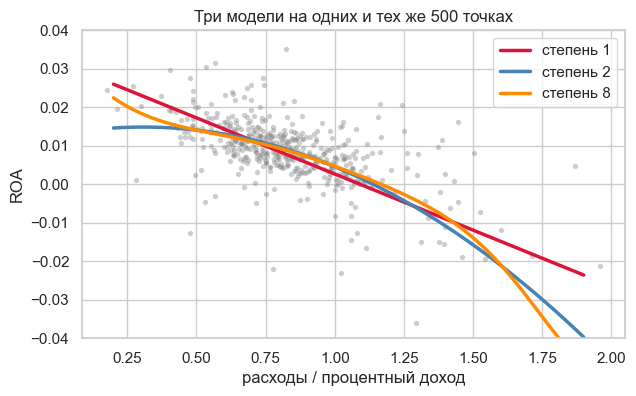

In [12]:
# Сетка значений x, на которой рисуем кривые
grid = pd.DataFrame({"m_cost_income": np.linspace(0.2, 1.9, 300)})

sns.scatterplot(data=small, x="m_cost_income", y="e_roa", alpha=0.4, s=15, color="grey")
for d, color in [(1, "crimson"), (2, "steelblue"), (8, "darkorange")]:
    model = poly_model(d).fit(X_small, y_small)
    plt.plot(grid["m_cost_income"], model.predict(grid), color=color, lw=2.5, label=f"степень {d}")

plt.ylim(-0.04, 0.04)          # иначе хвосты полинома растянут картинку
plt.title("Три модели на одних и тех же 500 точках")
plt.xlabel("расходы / процентный доход")
plt.ylabel("ROA")
plt.legend()
plt.show()

В середине, где точек много, все три кривые почти совпадают. Расходятся они на краях, где точек мало: степень 8 начинает изгибаться там, куда её тянут выбросы. Это и есть подгонка под шум или переобучения — на новых (тестовых) данных таких паттернов не будет. 

### 2.3 Отложенная выборка

Решение мы уже знаем из первой лекции: разделить данные на две части, обучить на одной, а ошибку измерить на другой. Разделим 500 строк пополам. Сакраментальные `train` и `test`. 

In [13]:
from sklearn.model_selection import train_test_split

# test_size=0.5 — половина строк уходит на проверку
X_train, X_val, y_train, y_val = train_test_split(
    X_small, y_small, test_size=0.5, random_state=SEED)

rows = []
for d in DEGREES:
    model = poly_model(d).fit(X_train, y_train)           # обучаем на одной половине
    rows.append({"степень": d,
                 "на обучении": rmse_bp(y_train, model.predict(X_train)),
                 "на проверке": rmse_bp(y_val, model.predict(X_val))})   # проверяем на другой

one_split = pd.DataFrame(rows).set_index("степень")
one_split.round(1)

,на обучении,на проверке
степень,,
1,99.6,100.6
2,93.8,100.7
3,91.6,105.7
4,91.2,107.9
5,91.2,108.0
6,91.2,107.8
7,91.2,108.2
8,91.2,107.8


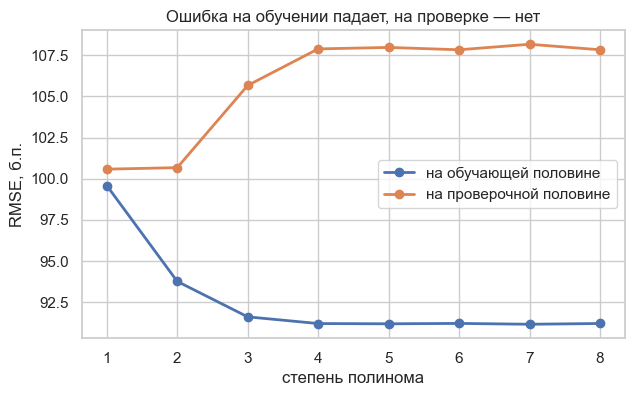

In [14]:
plt.plot(DEGREES, one_split["на обучении"], "o-", lw=2, label="на обучающей половине")
plt.plot(DEGREES, one_split["на проверке"], "o-", lw=2, label="на проверочной половине")
plt.title("Ошибка на обучении падает, на проверке — нет")
plt.xlabel("степень полинома")
plt.ylabel("RMSE, б.п.")
plt.legend()
plt.show()

Ошибка на обучающей половине падает, как и прежде. Ошибка на проверочной ведёт себя иначе: после первых степеней она **растёт** — модель начала запоминать шум обучающей половины.

### 2.4 У отложенной выборки есть проблема

Результат зависит от того, **какая именно половина** попала в проверку. Повторим то же самое десять раз с разными сидами.

In [15]:
val_curves = []      # сюда сложим 10 кривых ошибки на проверке
best_degrees = []    # и 10 "лучших" степеней

for s in range(10):
    # SEED + s — каждый раз другое деление пополам
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_small, y_small, test_size=0.5, random_state=SEED + s)

    curve = []
    for d in DEGREES:
        model = poly_model(d).fit(X_tr, y_tr)
        curve.append(rmse_bp(y_va, model.predict(X_va)))

    val_curves.append(curve)
    best_degrees.append(DEGREES[int(np.argmin(curve))])   # np.argmin — номер минимального элемента

print("лучшая степень в каждом из 10 делений:", best_degrees)

лучшая степень в каждом из 10 делений: [1, 3, 3, 2, 3, 3, 3, 3, 3, 1]


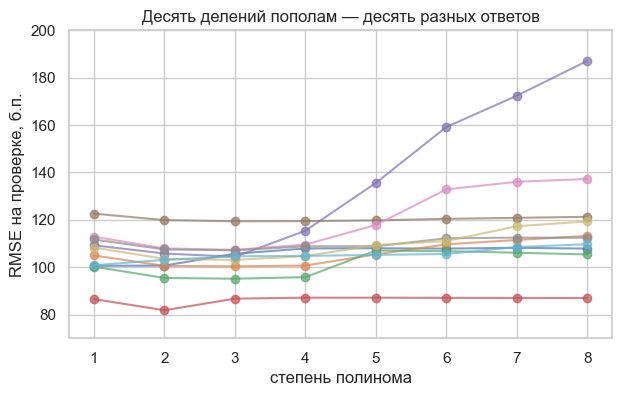

In [16]:
for curve in val_curves:
    plt.plot(DEGREES, curve, "o-", lw=1.5, alpha=0.7)

plt.ylim(70, 200)
plt.title("Десять делений пополам — десять разных ответов")
plt.xlabel("степень полинома")
plt.ylabel("RMSE на проверке, б.п.")
plt.show()

Каждая линия — оценка на половине выборки. У такой - отложенной - выборки есть два недостатка:

1. **Оценка сильно гуляет.** Уже при степени 1 одно деление обещает ошибку около 90 б.п., другое — больше 120. Лучшая степень тоже меняется от деления к делению. Это та же мысль, что во второй лекции про коэффициент: ошибка на прогоне — **оценка по случайной выборке**, и у неё есть разброс.
2. **Модель обучалась на половине данных.** Модель, которой мы потом будем пользоваться, обучится на всех 500 строках и будет точнее. Значит, отложенная выборка систематически **завышает** ошибку.

Оба недостатка лечит кросс-валидация.

## 3. Кросс-валидация

### 3.1 Идея k-fold

Разрежем строки на $k$ равных блоков. Дальше $k$ раундов: в каждом один блок откладываем на проверку, на остальных обучаем. В конце усредняем $k$ ошибок.

Каждая строка ровно один раз побывает в проверке и $k - 1$ раз — в обучении. Модель в каждом раунде видит $\frac{k-1}{k}$ данных, а не половину.

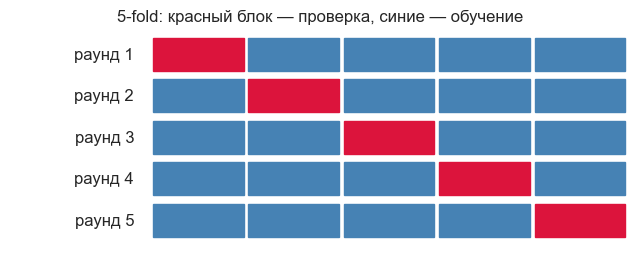

In [17]:
k = 5
fig, ax = plt.subplots(figsize=(8, 2.8))

for i in range(k):                 # i — номер раунда (строка картинки)
    for j in range(k):             # j — номер блока (столбец картинки)
        color = "crimson" if i == j else "steelblue"     # в раунде i проверяем блок i
        ax.add_patch(plt.Rectangle((j, k - 1 - i), 0.95, 0.8, color=color))
    ax.text(-0.2, k - 1 - i + 0.4, f"раунд {i + 1}", ha="right", va="center")

ax.set_xlim(-1.5, k)
ax.set_ylim(-0.2, k)
ax.axis("off")                     # оси здесь не нужны
ax.set_title("5-fold: красный блок — проверка, синие — обучение")
plt.show()

### 3.2 Кросс-валидация руками

Сначала напишем цикл сами — так видно, что внутри нет ничего, кроме уже знакомых `.fit()` и `.predict()`. `KFold` лишь нарезает номера строк на блоки.

In [19]:
from sklearn.model_selection import KFold

# 5 блоков; shuffle=True — перед нарезкой перемешать строки
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

fold_mse = []
# .split() на каждом раунде выдаёт два массива номеров строк: для обучения и для проверки
for train_idx, val_idx in kf.split(X_small):
    # .iloc[номера] — взять строки по порядковым номерам
    model = poly_model(2).fit(X_small.iloc[train_idx], y_small.iloc[train_idx])
    pred = model.predict(X_small.iloc[val_idx])
    fold_mse.append(mean_squared_error(y_small.iloc[val_idx], pred))

# Ошибка каждого раунда в б.п. — просто чтобы посмотреть
print("RMSE в каждом раунде, б.п.:", np.round(np.sqrt(fold_mse) * 10_000, 1))

# Итог: усредняем квадраты ошибок и только в конце берём корень
print("кросс-валидация, б.п.:     ", round(np.sqrt(np.mean(fold_mse)) * 10_000, 1))

RMSE в каждом раунде, б.п.: [ 80.8  98.3 113.5 111.3  93.8]
кросс-валидация, б.п.:      100.3


Даже внутри одной кросс-валидации раунды заметно различаются. Итоговое число — среднее по всем пяти, поэтому оно устойчивее каждого из них. Это наше истинное среднее, наблюдения - гуляние на стандартную ошибку от него. 

### 3.3 То же одной функцией

Цикл всегда одинаковый, поэтому в `sklearn` для него есть готовая функция `cross_val_score`. Обернём её в свою, которая сразу печатает RMSE в базисных пунктах. Этой функцией `cv_rmse` мы будем пользоваться до конца лекции.

In [21]:
from sklearn.model_selection import cross_val_score

# Ошибка кросс-валидации в б.п.
# cv — как резать на блоки; groups — понадобится в §5, пока не обращайте внимания.
# scoring="neg_mean_squared_error": sklearn возвращает MSE со знаком минус
# (у него принято "чем больше, тем лучше"), поэтому ставим минус обратно.
def cv_rmse(model, X, y, cv, groups=None):
    mse = -cross_val_score(model, X, y, cv=cv, groups=groups,
                           scoring="neg_mean_squared_error")
    return np.sqrt(mse.mean()) * 10_000

print("руками:          ", round(np.sqrt(np.mean(fold_mse)) * 10_000, 1))
print("cross_val_score: ", round(cv_rmse(poly_model(2), X_small, y_small, kf), 1))

руками:           100.3
cross_val_score:  100.3


### 3.4 Выбираем степень

Теперь посчитаем 10-fold кросс-валидацию для каждой степени и положим её поверх десяти кривых из §2.4.

In [25]:
kf10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

cv_curve = []
for d in DEGREES:
    cv_curve.append(cv_rmse(poly_model(d), X_small, y_small, kf10))

best_cv = DEGREES[int(np.argmin(cv_curve))]
print("10-fold, б.п.:", np.round(cv_curve, 1))
print("лучшая степень по кросс-валидации:", best_cv)

10-fold, б.п.: [100.9  98.5  99.   99.7 100.4 101.  102.6 104.7]
лучшая степень по кросс-валидации: 2


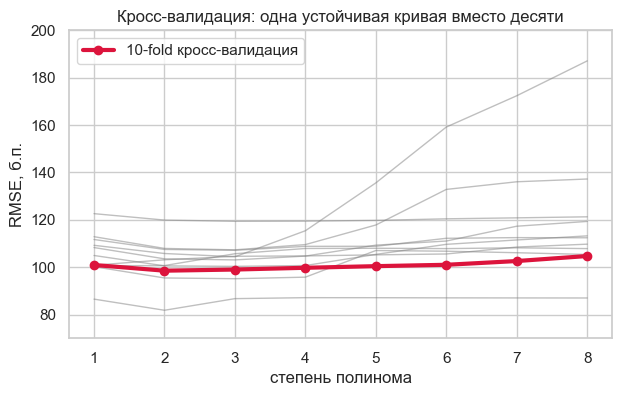

In [16]:
for curve in val_curves:           # серые: десять делений пополам из §2.4
    plt.plot(DEGREES, curve, color="grey", lw=1, alpha=0.5)
plt.plot(DEGREES, cv_curve, "o-", color="crimson", lw=3, label="10-fold кросс-валидация")

plt.ylim(70, 200)
plt.title("Кросс-валидация: одна устойчивая кривая вместо десяти")
plt.xlabel("степень полинома")
plt.ylabel("RMSE, б.п.")
plt.legend()
plt.show()

Красная кривая гладкая, у неё неглубокий минимум на степени 2, и дальше ошибка медленно растёт.

Кроме того, у нас есть еще аж 95 тысяч строк, которых модель не видела. Проверим, насколько кросс-валидация на 500 строках подобрала верные параметры. 

In [17]:
# Все строки, кроме наших 500: .drop убирает строки по индексу
rest = banks.drop(small.index)

rows = []
for d in DEGREES:
    model = poly_model(d).fit(X_small, y_small)            # обучаем на 500 строках
    rows.append({"степень": d,
                 "10-fold на 500 строках": cv_curve[d - 1],
                 "на остальных 95 тыс. строк": rmse_bp(rest["e_roa"], model.predict(rest[["m_cost_income"]]))})

pd.DataFrame(rows).set_index("степень").round(1)

,10-fold на 500 строках,на остальных 95 тыс. строк
степень,,
1,100.9,105.0
2,98.5,108.1
3,99.0,108.2
4,99.7,108.3
5,100.4,108.3
6,101.0,108.4
7,102.6,108.4
8,104.7,108.8


На самом деле на остальных строках лучшей оказалась **степень 1**, а не 2. Уровень ошибки тоже чуть выше, чем обещала кросс-валидация.

Но посмотрите на масштаб! Разница между степенями 1 и 2 на новых данных — около 3 б.п., а разброс между отдельными делениями пополам в §2.4 — десятки базисных пунктов. Кросс-валидация — это тоже оценка по 500 строкам. Зато она **устойчивая**: она не пообещает ошибку 90 б.п. только потому, что нам повезло с делением. Так на небольших данных можно сделать вполне корректные предположения о свойствах данных покрупнее. 

### 3.5 А что кросс-валидация делает с самой моделью?

Естественный вопрос: мы обучили 10 моделей и усреднили их ошибки. Какая из них пойдёт в работу? Может, надо усреднить их коэффициенты?

Посмотрим на эти 10 моделей. Чтобы коэффициенты было легко читать, возьмём прямую — степень 1.

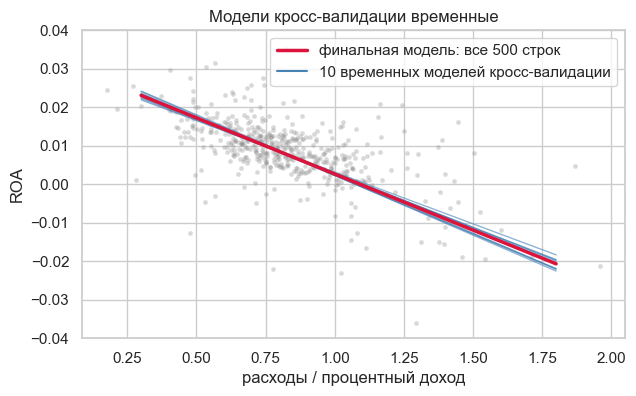

наклоны 10 временных моделей: [-0.0311 -0.0303 -0.0286 -0.0268 -0.0307 -0.0304 -0.029  -0.0281 -0.0288
 -0.0279]
среднее этих наклонов:         -0.02917
наклон финальной модели:       -0.02917


In [26]:
x_line = np.array([0.3, 1.8])        # две точки по x — через них рисуем каждую прямую
fold_slopes = []

sns.scatterplot(data=small, x="m_cost_income", y="e_roa", alpha=0.3, s=12, color="grey")

for train_idx, val_idx in kf10.split(X_small):
    # временная модель одного раунда: видит 9 блоков из 10
    temp = LinearRegression().fit(X_small.iloc[train_idx], y_small.iloc[train_idx])
    fold_slopes.append(temp.coef_[0])                  # .coef_ — наклоны модели sklearn, у нас он один
    plt.plot(x_line, temp.intercept_ + temp.coef_[0] * x_line, color="steelblue", lw=1, alpha=0.6)

# финальная модель: те же настройки, но все 500 строк
final = LinearRegression().fit(X_small, y_small)
plt.plot(x_line, final.intercept_ + final.coef_[0] * x_line, color="crimson", lw=2.5,
         label="финальная модель: все 500 строк")
plt.plot([], [], color="steelblue", label="10 временных моделей кросс-валидации")   # пустая линия — только для легенды

plt.ylim(-0.04, 0.04)
plt.title("Модели кросс-валидации временные")
plt.xlabel("расходы / процентный доход")
plt.ylabel("ROA")
plt.legend()
plt.show()

print("наклоны 10 временных моделей:", np.round(fold_slopes, 4))
print("среднее этих наклонов:        ", round(np.mean(fold_slopes), 5))
print("наклон финальной модели:      ", round(final.coef_[0], 5))

Ответ: **на самой модели кросс-валидация не отражается никак.** Порядок всегда такой:

1. **Кросс-валидация выбирает настройку** (степень, $k$, силу штрафа (об этом далее)) и оценивает ошибку.
2. **Временные модели выбрасываются.** Они нужны были только для того, чтобы померить ошибку на данных, которых модель не видела.
3. **Финальную модель обучают заново на всех данных** с выбранной настройкой. Именно она идёт в работу, и именно её качество оценивала кросс-валидация — даже чуть пессимистично. 

Усреднять коэффициенты незачем: каждая временная модель видела 90 % **тех же самых** строк, поэтому их среднее совпало с моделью на всех данных до пятого знака — это видно выше. А финальная модель видела больше. Отдельная сильная идея — усреднять **прогнозы** многих моделей, обученных на разных выборках, — называется бэггингом; до неё дойдём в лекции про деревья.

### 3.6 Leave-one-out

Крайний случай k-fold — $k = n$: каждая строка по очереди одна составляет проверочный блок. Это называется **leave-one-out** (LOOCV).

* Плюс: модель в каждом раунде обучается на $n - 1$ строке, почти на всех данных.
* Минус: $n$ обучений вместо 5 или 10. На 500 строках это нестрашно, на 95 тысячах — уже долго.

Это крайний случай желания «пощупать» данные со всех сторон. 

In [27]:
from sklearn.model_selection import LeaveOneOut

rows = []
for d in [1, 2, 3, 4]:
    rows.append({"степень": d,
                 "10-fold (10 обучений)": cv_curve[d - 1],
                 "leave-one-out (500 обучений)": cv_rmse(poly_model(d), X_small, y_small, LeaveOneOut())})

pd.DataFrame(rows).set_index("степень").round(1)

,10-fold (10 обучений),leave-one-out (500 обучений)
степень,,
1,100.9,100.7
2,98.5,98.1
3,99.0,98.6
4,99.7,99.3


Числа почти совпадают, а работы в 50 раз больше. Поэтому на практике почти всегда берут **5 или 10 блоков**: это хороший компромисс между точностью оценки и временем.

## 4. Бутстрап

### 4.1 Идея

Во второй лекции мы узнали, что такое стандартная ошибка: прогнали 300 циклов, каждый раз брали **новые** 500 строк из 95 тысяч и смотрели, как гуляет наклон. Разброс получился 0.0030.

В жизни чаще всего выборка у нас одна. **Бутстрап** предлагает хитрость: притвориться, что наша выборка и есть вся совокупность, и тянуть новые выборки **из неё самой** — того же размера, но **с возвращением**. Одна и та же строка может попасть в новую выборку несколько раз, а какая-то не попадёт вовсе.

Посмотрим на десяти числах.

In [28]:
rng = np.random.default_rng(SEED)      # генератор случайных чисел с сидом
numbers = np.arange(1, 11)             # числа от 1 до 10

print("исходная выборка:  ", numbers)
for i in range(3):
    # replace=True — с возвращением: вытянутое число возвращается обратно и может выпасть снова
    resample = rng.choice(numbers, size=10, replace=True)
    print("бутстрап-выборка:  ", np.sort(resample))

исходная выборка:   [ 1  2  3  4  5  6  7  8  9 10]
бутстрап-выборка:   [ 1  2  3  4  5  5  6  7  9 10]
бутстрап-выборка:   [ 1  1  3  4  7  8  9  9 10 10]
бутстрап-выборка:   [3 5 5 6 7 8 8 8 9 9]


В каждой бутстрап-выборке одни числа повторяются, других нет. В среднем в неё попадает около 63 % разных исходных строк. Этого разнообразия и хватает, чтобы оценить, как гуляла бы статистика.

### 4.2 Стандартная ошибка коэффициента

Возьмём наши 500 строк и 1000 раз оценим регрессию на бутстрап-выборках.

In [30]:
boot_betas = []
for b in range(1000):
    # .sample(n, replace=True) — n строк с возвращением; сид свой на каждом шаге
    boot_sample = small.sample(len(small), replace=True, random_state=SEED + b)
    boot_fit = smf.ols("e_roa ~ m_cost_income", data=boot_sample).fit()
    boot_betas.append(boot_fit.params["m_cost_income"])

boot_betas = np.array(boot_betas)

# Для сравнения: две формулы из лекции 2 на тех же 500 строках
fit_robust = smf.ols("e_roa ~ m_cost_income", data=small).fit(cov_type="HC1")

print(f"бутстрап (разброс 1000 оценок):  {boot_betas.std(ddof=1):.4f}")
print(f"обычная формула:                 {fit_small.bse['m_cost_income']:.4f}")
print(f"робастная формула HC1:           {fit_robust.bse['m_cost_income']:.4f}")
print(f"эксперимент из лекции 2:         0.0030")

бутстрап (разброс 1000 оценок):  0.0035
обычная формула:                 0.0017
робастная формула HC1:           0.0037
эксперимент из лекции 2:         0.0030


Бутстрап **не знал** ни про гетероскедастичность, ни про робастные формулы. Он просто перетасовывал строки — и получил почти то же, что HC1, и близко к эксперименту из второй лекции. Помним, что обычная формула занижает разброс вдвое. 

Из бутстрап-оценок сразу получается и доверительный интервал: отрезаем по 2.5 % оценок с каждого края. Это называется **перцентильный интервал**. А порог - $\alpha$'ой. 

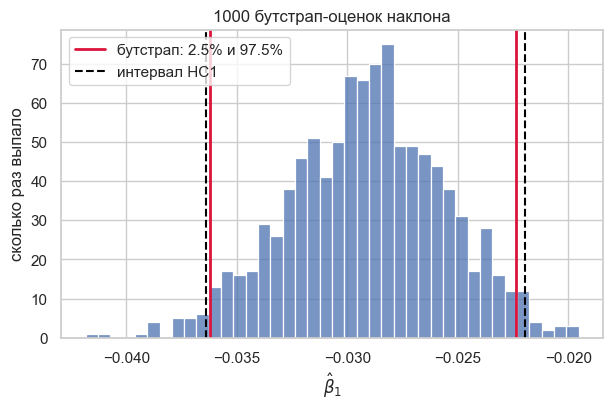

бутстрап: [-0.0362, -0.0224]
HC1:      [-0.0364, -0.0220]


In [31]:
# np.percentile — значение, ниже которого лежит заданный процент оценок
lo, hi = np.percentile(boot_betas, [2.5, 97.5])
lo_hc1, hi_hc1 = fit_robust.conf_int().loc["m_cost_income"]

sns.histplot(boot_betas, bins=40)
plt.axvline(lo, color="crimson", lw=2, label="бутстрап: 2.5% и 97.5%")
plt.axvline(hi, color="crimson", lw=2)
plt.axvline(lo_hc1, color="black", ls="--", lw=1.5, label="интервал HC1")
plt.axvline(hi_hc1, color="black", ls="--", lw=1.5)
plt.title("1000 бутстрап-оценок наклона")
plt.xlabel("$\\hat\\beta_1$")
plt.ylabel("сколько раз выпало")
plt.legend()
plt.show()

print(f"бутстрап: [{lo:.4f}, {hi:.4f}]")
print(f"HC1:      [{lo_hc1:.4f}, {hi_hc1:.4f}]")

### 4.3 Когда формулы нет вовсе

Для коэффициента регрессии формула есть, и бутстрапом мы ее эмпирически оценили. 
По-настоящему полезенбутстрап там, где формулы **нет**: медиана, перцентиль, отношение двух оценок, ошибка модели. Например, какова стандартная ошибка **медианного** ROA по нашим 500 строкам?

In [32]:
boot_medians = []
for b in range(1000):
    boot_sample = small.sample(len(small), replace=True, random_state=SEED + b)
    boot_medians.append(boot_sample["e_roa"].median())

print(f"медианный ROA: {small['e_roa'].median() * 10_000:.0f} б.п.")
print(f"стандартная ошибка медианы (бутстрап): {np.std(boot_medians, ddof=1) * 10_000:.1f} б.п.")

медианный ROA: 88 б.п.
стандартная ошибка медианы (бутстрап): 4.0 б.п.


Тот же цикл, другая статистика — ответ тот же. Никакой новой теории не понадобилось. Но понадобилось больше комьюта. 

### 4.4 Бутстрап на панели: что именно размножать

Во второй лекции мы видели, что остатки одного банка скоррелированы во времени, и вводили ограничение **кластерными** стандартными ошибками. Бутстрап по строкам делает то же, что стандартный подход: делает предположение о независимости строк. Однако для панели это неверно.

Решение — бутстрепить **банки целиком**: тянуть с возвращением не строки, а банки, и забирать каждый вытянутый банк со всеми его кварталами.

Возьмём 100 случайных банков со всей их историей.

In [33]:
# .drop_duplicates() — список банков без повторов; из него берём 100 случайных
certs100 = banks["cert"].drop_duplicates().sample(100, random_state=SEED)

# .isin(список) — строка остаётся, если её банк есть в списке
panel100 = banks[banks["cert"].isin(certs100)]
print("банков:", panel100["cert"].nunique(), "| строк:", len(panel100))

formula = "e_roa ~ m_cost_income + a_npl_gross_loans"

# Три формулы стандартных ошибок из лекции 2
fit_plain = smf.ols(formula, data=panel100).fit()
fit_hc1 = smf.ols(formula, data=panel100).fit(cov_type="HC1")
fit_cluster = smf.ols(formula, data=panel100).fit(cov_type="cluster",
                                                  cov_kwds={"groups": panel100["cert"]})

банков: 100 | строк: 4617


In [34]:
# Для бутстрапа по банкам: делаем cert индексом таблицы.
# Тогда .loc[список банков] вернёт все их строки — и повторит банк, если он в списке дважды.
by_bank = panel100.set_index("cert")
bank_list = certs100.to_numpy()

row_boot = []     # коэффициенты при бутстрапе по строкам
bank_boot = []    # коэффициенты при бутстрапе по банкам

for b in range(300):
    # по строкам: как в §4.2
    s_rows = panel100.sample(len(panel100), replace=True, random_state=SEED + b)
    row_boot.append(smf.ols(formula, data=s_rows).fit().params["m_cost_income"])

    # по банкам: тянем 100 банков с возвращением и берём все их кварталы
    chosen = np.random.default_rng(SEED + b).choice(bank_list, size=len(bank_list), replace=True)
    s_banks = by_bank.loc[chosen].reset_index()
    bank_boot.append(smf.ols(formula, data=s_banks).fit().params["m_cost_income"])

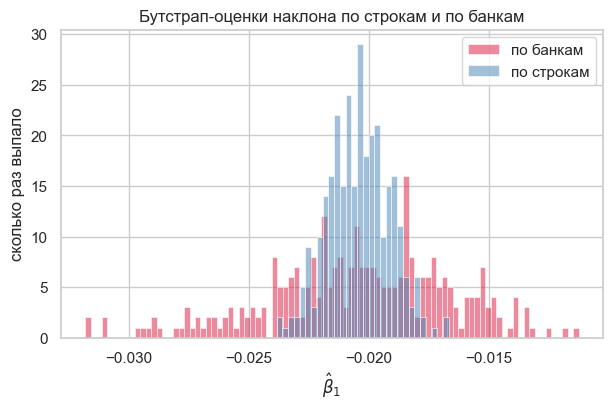

In [42]:
# print two booted distributions to compare
sns.histplot(bank_boot, bins=90, color="crimson", alpha=0.5, label="по банкам")
sns.histplot(row_boot, bins=30, color="steelblue", alpha=0.5, label="по строкам")
plt.title("Бутстрап-оценки наклона по строкам и по банкам")
plt.xlabel("$\\hat\\beta_1$")
plt.ylabel("сколько раз выпало")
plt.legend()
plt.show()

А какой ответ правильный? У нас 2 267 банков, так что можно 200 раз взять **независимые** сотни банков и посмотреть, как на самом деле гуляет коэффициент.

In [37]:
true_betas = []
for j in range(200):
    other100 = banks["cert"].drop_duplicates().sample(100, random_state=5_000 + j)
    fit_j = smf.ols(formula, data=banks[banks["cert"].isin(other100)]).fit()
    true_betas.append(fit_j.params["m_cost_income"])

pd.DataFrame({
    "стандартная ошибка наклона при cost/income": [
        fit_plain.bse["m_cost_income"],
        fit_hc1.bse["m_cost_income"],
        np.std(row_boot, ddof=1),
        fit_cluster.bse["m_cost_income"],
        np.std(bank_boot, ddof=1),
        np.std(true_betas, ddof=1)],
}, index=["обычная формула", "робастная HC1", "бутстрап по строкам",
          "кластерная по банкам", "бутстрап по банкам",
          "истина: 200 независимых сотен банков"]).round(4)

,стандартная ошибка наклона при cost/income
обычная формула,0.0006
робастная HC1,0.0013
бутстрап по строкам,0.0013
кластерная по банкам,0.0037
бутстрап по банкам,0.0038
истина: 200 независимых сотен банков,0.0030


Что же мы видим:

* **Обычная формула, HC1 и бутстрап по строкам** считают каждую строку независимой. Они дают от 0.0006 до 0.0013 — в два-пять раз меньше истины.
* **Кластерная формула и бутстрап по банкам** признают, что независимы только банки. Они дают около 0.004 — ближе к истине в 0.003

Бутстрап по строкам и HC1 совпали, бутстрап по банкам и кластерная — тоже: это одни и те же идеи, записанные разными способами.

> **Вывод: в панели независимая единица — банк, а не строка.** 

Эта мысль понадобится через минуту, когда мы будем делить данные для проверки модели.

## 5. Сущностная утечка

### 5.1 Настоящая задача: ROA через год

До сих пор мы объясняли ROA квартала показателями **того же** квартала. Для объяснения это нормально, для прогнозирования не имеет смысла: когда в отчётности уже видны расходы и просрочка, в ней же уже виден и ROA. Предсказывать нечего.

Вопрос интереснее звучит иначе: **видно ли заранее?** Поэтому дальше модель будет работать так:

| | когда известно | пример |
|---|---|---|
| признаки | сегодня | cost/income, просрочка, капитал… банка 7074 на 31.03.2007 |
| отклик | через год | ROA того же банка на 31.03.2008 |

Отклик возьмём из той же таблицы: для каждой строки найдём строку **того же банка на 4 квартала позже**. Во второй лекции мы уже сдвигали колонку внутри банка через `.groupby("cert")[...].shift(lag)`. Там сдвиг был назад, в прошлое; `shift(-4)` сдвигает вперёд — забирает значение из строки на 4 позиции ниже.

**Нюанс:** сдвигать надо в исходной таблице `panel`, **до фильтра**. Фильтр выбросил часть кварталов, и в отфильтрованной таблице «4 строки ниже» — это часто уже не год, а полтора или два.

In [43]:
# Сортируем исходную таблицу: внутри банка кварталы идут по порядку
panel = panel.sort_values(["cert", "repdte"])

# shift(-4) внутри каждого банка: значение из строки на 4 квартала позже
panel["roa_next"] = panel.groupby("cert")["e_roa"].shift(-4)
panel["date_next"] = panel.groupby("cert")["repdte"].shift(-4)

# Проверка: между датами должен быть ровно год, 365 или 366 дней
days = (panel["date_next"] - panel["repdte"]).dt.days
print(days.value_counts().head())

365.0    107399
366.0     34532
456.0         1
Name: count, dtype: int64


In [44]:
# Если у банка пропущен квартал, "4 строки ниже" — уже не год. Такие отклики стираем.
# np.nan — пустое значение (пропуск)
panel.loc[~days.isin([365, 366]), "roa_next"] = np.nan

# Для сравнения — как НЕ надо: тот же сдвиг, но в уже отфильтрованной таблице
days_wrong = (banks.groupby("cert")["repdte"].shift(-4) - banks["repdte"]).dt.days

print("сдвиг до фильтра:    строк с откликом ровно через год —", panel.loc[banks.index, "roa_next"].notna().sum())
print("сдвиг после фильтра: строк, где 4 строки ниже — ровно год, —", days_wrong.isin([365, 366]).sum())

сдвиг до фильтра:    строк с откликом ровно через год — 89797
сдвиг после фильтра: строк, где 4 строки ниже — ровно год, — 48712


Сдвиг после фильтра потерял бы почти половину строк. В общем, на чистке данных легко погореть. 

Теперь соберём таблицу для прогноза. Признаков возьмём одиннадцать, из разных блоков CAMELS. Среди них сегодняшний ROA — он известен сегодня, и было бы странно его не использовать. И обе меры капитала: `c_equity_assets` и `c_tier1_leverage` — те самые близнецы из второй лекции, они понадобятся нам в далее.

In [45]:
FEATURES = ["e_roa", "m_cost_income", "a_npl_gross_loans", "a_nco_rate",
            "c_equity_assets", "c_tier1_leverage", "e_nim", "s_securities_assets",
            "l_liquid_assets_ratio", "a_cre_concentration", "l_brokered_share"]

# Переносим отклик в отфильтрованную таблицу.
# pandas сопоставляет строки по индексу — номеру строки в исходной таблице panel.
banks["roa_next"] = panel["roa_next"]

# Таблица для прогноза: без пропусков и с тем же диапазоном ROA, что в фильтре
fc = banks.dropna(subset=FEATURES + ["roa_next"])
fc = fc[fc["roa_next"].between(-0.10, 0.10)].reset_index(drop=True)

print("строк:", len(fc), "| банков:", fc["cert"].nunique())
print("корреляция ROA сегодня и через год:", round(fc["e_roa"].corr(fc["roa_next"]), 3))

строк: 89174 | банков: 2197
корреляция ROA сегодня и через год: 0.52


Два решения, которые мы только что приняли:

1. **Строки без ROA через год выпали.** Это последние кварталы каждого банка — и в том числе банки, которые **закрылись в течение года**. Самые интересные банки отфильтрованы.
2. **ROA через год мы ограничили диапазоном ±10 %** — это фильтр по будущему. Катастрофы мы из задачи убрали сознательно: предсказывать дефолт — тема следующей лекции.

Итак, выводы этой половины лекции — про **банки, которые проработали ещё год без приключений**.

Корреляция ROA сегодня и через год — 0.52. Прибыльность довольно устойчива.

### 5.2 Что такое сущностная утечка

Вспомним вывод §4.4: независимая единица — банк. А теперь представьте обычное случайное деление строк на обучение и проверку, как в первой лекции. Кварталы **одного и того же банка** окажутся по обе стороны. Банк в тесте для модели не новый: его соседний квартал — с почти теми же показателями и почти тем же будущим ROA — лежит в трейне.

Тогда проверка отвечает на вопрос «насколько хорошо модель предсказывает банки, **которые она уже видела**». А нам обычно нужно «насколько хорошо она предскажет **новый** банк». Это и есть **сущностная утечка**: одна сущность (банк) протекла из обучения в проверку. В результате у нас растет качество на обучении и падает - на проде. Ужасный сценарий. 

Но насколько кварталы одного банка похожи друг на друга? Возьмём 400 случайных банков и для каждой строки найдём ближайшую по показателям строку.

In [47]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# 400 случайных банков со всеми их кварталами — чтобы расчёты шли быстро
certs400 = fc["cert"].drop_duplicates().sample(400, random_state=SEED)
fc400 = fc[fc["cert"].isin(certs400)]
print("строк:", len(fc400))

# StandardScaler приводит признаки к одному масштабу (подробно — в §8).
# Без него расстояние считалось бы почти только по признаку с самым большим разбросом.
Z = StandardScaler().fit_transform(fc400[FEATURES])

# Для каждой строки ищем 2 ближайшие: первая — она сама, вторая — настоящий сосед
nn = NearestNeighbors(n_neighbors=2).fit(Z)
_, idx = nn.kneighbors(Z)                  # idx[:, 1] — номер ближайшего соседа

cert_values = fc400["cert"].to_numpy()
same_bank = cert_values[idx[:, 1]] == cert_values
print(f"ближайший сосед — тот же банк: {same_bank.mean():.0%} строк")

строк: 16331
ближайший сосед — тот же банк: 81% строк


Для подавляющего большинства строк ближайший «похожий банк» — это **тот же самый банк** в другом квартале. Метод ближайших соседей при случайном делении будет находить в обучении не похожие банки, а тот же самый через время. 

### 5.3 Случайное деление против деления по банкам

В `sklearn` есть `GroupKFold`: он режет данные на блоки так, что **все строки одной группы попадают в один блок**. Группа у нас — банк (`groups=cert`). Тогда в каждом раунде проверка состоит только из банков, которых модель не видела.

Сравним две кросс-валидации на KNN с разным числом соседей.

In [49]:
from sklearn.model_selection import GroupKFold
from sklearn.neighbors import KNeighborsRegressor

X400 = fc400[FEATURES]
y400 = fc400["roa_next"]
g400 = fc400["cert"]                                            # группы — банки

random_cv = KFold(n_splits=5, shuffle=True, random_state=SEED)  # случайное деление строк
group_cv = GroupKFold(n_splits=5)                               # деление по банкам

rows = []
for k in [1, 5, 10, 20, 50, 100, 200, 500]:
    knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    rows.append({"соседей k": k,
                 "случайное деление": cv_rmse(knn, X400, y400, random_cv),
                 "деление по банкам": cv_rmse(knn, X400, y400, group_cv, groups=g400)})

leak = pd.DataFrame(rows).set_index("соседей k")
leak.round(1)

,случайное деление,деление по банкам
соседей k,,
1,128.6,147.5
5,103.6,114.3
10,102.2,109.8
20,102.9,107.6
50,104.2,107.1
100,105.6,107.5
200,107.2,108.5
500,110.1,110.8


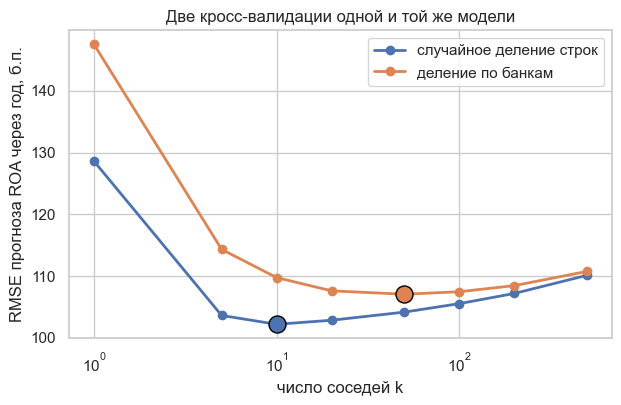

случайное деление выбирает k = 10
деление по банкам выбирает k = 50


In [50]:
plt.plot(leak.index, leak["случайное деление"], "o-", lw=2, label="случайное деление строк")
plt.plot(leak.index, leak["деление по банкам"], "o-", lw=2, label="деление по банкам")

# Отмечаем минимум каждой кривой: .idxmin() — индекс (здесь k) минимального значения
for col, color in [("случайное деление", "C0"), ("деление по банкам", "C1")]:
    plt.scatter([leak[col].idxmin()], [leak[col].min()], s=150, color=color, edgecolor="black", zorder=5)

plt.xscale("log")                  # логарифмическая шкала: k от 1 до 500
plt.title("Две кросс-валидации одной и той же модели")
plt.xlabel("число соседей k")
plt.ylabel("RMSE прогноза ROA через год, б.п.")
plt.legend()
plt.show()

print("случайное деление выбирает k =", leak["случайное деление"].idxmin())
print("деление по банкам выбирает k =", leak["деление по банкам"].idxmin())

Минуточку! деление по банкам ведь показало ошибку **хуже**. Может, оно просто хуже?

Нет. Модель в обеих колонках одна и та же — различается только **честность оценки**. Проверим, какая из двух кросс-валидаций сказала правду: обучим KNN на тех же 400 банках и применим его к 400 **другим** банкам, которых не было ни в одной кросс-валидации.

In [52]:
# 400 других банков: их не было ни в обучении, ни в одной из двух кросс-валидаций
other = fc[~fc["cert"].isin(certs400)]
new_certs = other["cert"].drop_duplicates().sample(400, random_state=SEED + 1)
new_banks = other[other["cert"].isin(new_certs)]

# Обучаем KNN на всех строках 400 банков и проверяем на новых банках
new_errors = []
for k in leak.index:
    knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    knn.fit(X400, y400)
    new_errors.append(rmse_bp(new_banks["roa_next"], knn.predict(new_banks[FEATURES])))

check = leak.copy()
check["на новых банках"] = new_errors

print("лучшее k на новых банках:", check["на новых банках"].idxmin())
check.round(1)

лучшее k на новых банках: 50


,случайное деление,деление по банкам,на новых банках
соседей k,,,
1,128.6,147.5,145.5
5,103.6,114.3,114.7
10,102.2,109.8,110.1
20,102.9,107.6,108.7
50,104.2,107.1,108.0
100,105.6,107.5,108.2
200,107.2,108.5,109.0
500,110.1,110.8,111.0


Сравните последнюю колонку с двумя первыми:

* **Деление по банкам почти точно угадало** ошибку на новых банках: при $k = 10$ — 109.8 против 110.1, при $k = 50$ — 107.1 против 108.0.
* **Случайное деление пообещало меньше**, чем получилось на деле: 102.2 и 104.2.
* **$k = 50$, выбранное делением по банкам, на новых банках действительно лучше**, чем $k = 10$ из случайного деления: 108.0 против 110.1.

Более низкая ошибка при случайном делении — не достоинство, а иллюзия достоинства.


Получается:

* **При случайном делении ошибка всегда ниже.** Сильнее всего при $k = 1$: модель находит в обучении соседний квартал того же банка и почти списывает ответ.
* **Разница не катастрофическая** — несколько базисных пунктов у разумных $k$. Будущий ROA всё-таки шумный, и списать его целиком не выходит.
* **Главный проблема — в выборе модели.** Случайное деление выбирает маленькое $k$: модель, которая хорошо узнаёт знакомые банки. Деление по банкам выбирает $k$ побольше — модель, которая лучше обобщает на новые.

Линейная регрессия тоже чувствует разницу, хотя «списывать» у соседей не умеет.

In [51]:
ols = LinearRegression()
print("линейная регрессия, случайное деление:", round(cv_rmse(ols, X400, y400, random_cv), 1), "б.п.")
print("линейная регрессия, деление по банкам:", round(cv_rmse(ols, X400, y400, group_cv, groups=g400), 1), "б.п.")

линейная регрессия, случайное деление: 107.5 б.п.
линейная регрессия, деление по банкам: 113.2 б.п.


> **Правило.** Сначала решите, к чему модель будут применять. К новым банкам — делите по банкам. Случайное деление строк честно только тогда, когда строки действительно независимы, а в панели так почти не бывает.

## 6. Временная утечка

### 6.1 Обучили на прошлом — применили в будущем

Прогнозной моделью пользуются **вперёд во времени**: обучают на том, что уже случилось, и применяют к тому, что ещё не случилось. Проверка должна повторять эту ситуацию.

При случайном делении строки 2009 года попадают и в обучение, и в тест. Модель узнаёт, что «в 2009 году всем было плохо», от других банков того же года — в реальном прогнозе такого знания у неё не было бы.

Есть и вторая тонкость, из-за отклика. Строка за 2007 год содержит ROA **2008 года**. Если обучаться на строках 2007 года, а проверять на 2008-м, в обучение уже протекли ответы из проверочного периода. Поэтому между обучением и проверкой нужен **зазор длиной в горизонт прогноза** — один год.

Проведём эксперимент: обучим модель на 2001–2006, пропустим 2007 и применим к 2008–2009.

In [53]:
year = fc["repdte"].dt.year          # .dt.year — год из даты

past = fc[year <= 2006]              # обучение: 2001-2006
crisis = fc[year.isin([2008, 2009])] # проверка: 2008-2009 (2007 — зазор)

ols = LinearRegression()

# Что пообещала бы кросс-валидация, если бы у нас были только данные до 2006 года
cv_estimate = cv_rmse(ols, past[FEATURES], past["roa_next"], group_cv, groups=past["cert"])

# Что случилось на самом деле
ols.fit(past[FEATURES], past["roa_next"])
errors = crisis["roa_next"] - ols.predict(crisis[FEATURES])     # факт минус прогноз

print(f"кросс-валидация на 2001-2006 обещает: {cv_estimate:.0f} б.п.")
print(f"реальная ошибка в 2008-2009:          {np.sqrt((errors ** 2).mean()) * 10_000:.0f} б.п.")
print(f"средняя ошибка (факт минус прогноз):  {errors.mean() * 10_000:+.0f} б.п.")

кросс-валидация на 2001-2006 обещает: 77 б.п.
реальная ошибка в 2008-2009:          197 б.п.
средняя ошибка (факт минус прогноз):  -68 б.п.


Кросс-валидация на спокойных годах, даже честная, по банкам, пообещала одно — а в кризис ошибка оказалась в **два с половиной раза больше**. И она не просто больше, она **однобокая**: средняя ошибка отрицательная, то есть модель систематически обещала банкам более высокий ROA. Модели, обученной на периоде подъёма, просто неоткуда узнать, что бывают и кризисы. 

### 6.2 Прогноз шаг за шагом

Корректная схема для прогнозной модели — идти **вдоль оси времени**. Для каждого года $Y$:

1. обучаем модель на всех строках до года $Y - 2$ включительно (год $Y - 1$ — зазор);
2. проверяем на строках года $Y$;
3. сдвигаемся на год вперёд.

Так каждый прогноз сделан ровно в тех условиях, в каких его сделали бы тогда.

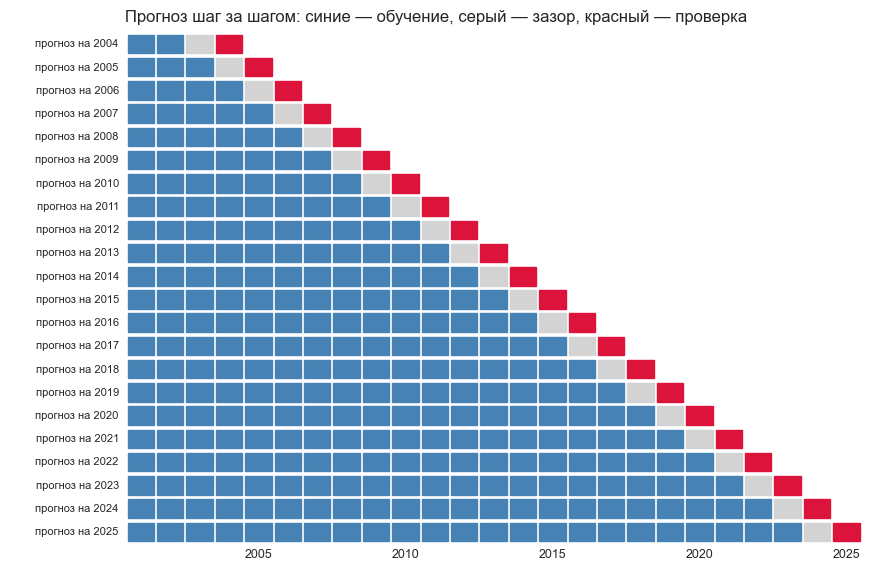

In [54]:
data_years = list(range(2001, 2026))       # годы, которые есть в таблице (по столбцам)
target_years = list(range(2004, 2026))     # годы, для которых делаем прогноз (по строкам)
n_rows = len(target_years)

fig, ax = plt.subplots(figsize=(11, 7))
for i, Y in enumerate(target_years):       # i — номер шага (строка картинки)
    for j, yr in enumerate(data_years):    # j — год данных (столбец картинки)
        if yr <= Y - 2:
            color = "steelblue"            # обучение
        elif yr == Y - 1:
            color = "lightgrey"            # зазор
        elif yr == Y:
            color = "crimson"              # проверка
        else:
            continue                       # будущее: на этом шаге его ещё нет, не рисуем
        ax.add_patch(plt.Rectangle((j, n_rows - 1 - i), 0.9, 0.8, color=color))
    ax.text(-0.3, n_rows - 1 - i + 0.4, f"прогноз на {Y}", ha="right", va="center", fontsize=8)

for j, yr in enumerate(data_years):        # подписи годов под схемой
    if yr % 5 == 0:
        ax.text(j + 0.45, -0.7, str(yr), ha="center", fontsize=9)

ax.set_xlim(-4, len(data_years))
ax.set_ylim(-1.2, n_rows)
ax.axis("off")
ax.set_title("Прогноз шаг за шагом: синие — обучение, серый — зазор, красный — проверка")
plt.show()

Сравните со схемой 5-fold. Там каждый блок побывал в проверке, а обучение всегда было со всех сторон от него — и из прошлого, и из будущего. Здесь обучение **всегда слева** от проверки, окно обучения растёт с каждым шагом, а серый зазор не даёт отклику из обучения заглянуть в проверочный год.

(В `sklearn` похожая схема есть готовой — `TimeSeriesSplit` с параметром `gap`. Но он режет по номерам строк, а не по датам, поэтому на панели, где в каждом квартале тысячи банков, проще и надёжнее написать цикл по годам самим.)

In [55]:
rows = []
all_errors = []                      # сюда сложим ошибки всех лет подряд

for Y in range(2004, 2026):
    train_part = fc[year <= Y - 2]   # всё, что было известно
    test_part = fc[year == Y]        # год, который прогнозируем

    ols = LinearRegression().fit(train_part[FEATURES], train_part["roa_next"])
    err = test_part["roa_next"] - ols.predict(test_part[FEATURES])

    all_errors.extend(err)           # .extend добавляет в список все элементы сразу
    rows.append({"год": Y,
                 "RMSE, б.п.": float(np.sqrt((err ** 2).mean()) * 10_000),
                 "средняя ошибка, б.п.": float(err.mean() * 10_000)})

forward = pd.DataFrame(rows).set_index("год")
forward.round(1)

,"RMSE, б.п.","средняя ошибка, б.п."
год,,
2004,67.9,0.6
2005,71.4,-5.2
2006,106.7,-31.7
2007,200.8,-91.3
2008,217.8,-93.7
2009,165.9,-12.5
2010,143.3,20.6
2011,119.0,27.0
2012,91.5,14.5


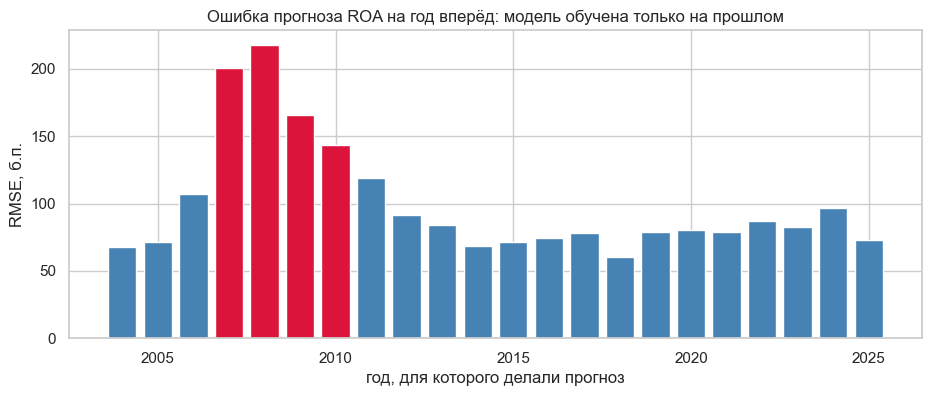

In [56]:
# Цвет столбика: кризисные годы — красным
colors = ["crimson" if 2007 <= y <= 2010 else "steelblue" for y in forward.index]

plt.figure(figsize=(11, 4))
plt.bar(forward.index, forward["RMSE, б.п."], color=colors)
plt.title("Ошибка прогноза ROA на год вперёд: модель обучена только на прошлом")
plt.xlabel("год, для которого делали прогноз")
plt.ylabel("RMSE, б.п.")
plt.show()

In [57]:
honest = np.sqrt(np.mean(np.array(all_errors) ** 2)) * 10_000
random_all = cv_rmse(LinearRegression(), fc[FEATURES], fc["roa_next"], random_cv)

print(f"случайная кросс-валидация по всем годам:  {random_all:.0f} б.п.")
print(f"честный прогноз шаг за шагом:            {honest:.0f} б.п.")

случайная кросс-валидация по всем годам:  108 б.п.
честный прогноз шаг за шагом:            119 б.п.


Что из этого следует:

1. **Честная оценка хуже случайной.** Случайное деление перемешивает годы и позволяет модели учиться на «соседях по кризису».
2. **Слона-то мы и не заметили.** В спокойные годы ошибка 60–100 б.п., в 2007–2008 — вдвое выше. Модель ошибается сильнее всего ровно тогда, когда прогноз нужнее всего. Средняя ошибка за 22 года этого не показывает — показывает только разбивка по времени.

> **Правило.** Если модель будут применять к будущему — проверяйте её на будущем, и оставляйте между обучением и проверкой зазор длиной в горизонт прогноза.

## 7. Целевая утечка

### 7.1 Признак, который знает ответ

**Целевая утечка** — это признак, который содержит сам отклик или посчитан из него. Модель с таким признаком выглядит блестяще, но на проде бесполезна: в момент прогноза этого признака ещё нет.

Самый наглядный пример — на секунду вернёмся к объяснению ROA того же квартала и добавим в модель ROE.

In [58]:
for f in ["e_roa ~ m_cost_income",
          "e_roa ~ m_cost_income + e_roe",
          "e_roa ~ m_cost_income + e_roe * c_equity_assets"]:
    fit = smf.ols(f, data=banks).fit()
    print(f"R^2 = {fit.rsquared:.3f}   {f}")

R^2 = 0.258   e_roa ~ m_cost_income
R^2 = 0.819   e_roa ~ m_cost_income + e_roe
R^2 = 0.994   e_roa ~ m_cost_income + e_roe * c_equity_assets


$R^2$ взлетел с 0.26 до 0.99. Это не открытие, а тождество:

$$ \text{ROA} = \frac{\text{прибыль}}{\text{активы}} = \frac{\text{прибыль}}{\text{капитал}} \cdot \frac{\text{капитал}}{\text{активы}} = \text{ROE} \cdot \frac{\text{капитал}}{\text{активы}} $$

ROE — это та же прибыль, только поделённая на другое число. Произведение `e_roe * c_equity_assets` восстанавливает ROA почти в точности.

Два признака утечек:

1. **Подозрительно хороший результат**
2. **Известно ли УЖЕ значение признака в момент прогноза, при этом ответ ЕЩЕ не известен?**

### 7.2 Тихая утечка

Настоящие утечки редко бывают такими очевидными. Пример хорошей ошибки: хочется дать модели «репутацию» банка — его **средний ROA**. Проще всего посчитать его по всей таблице.

In [59]:
# Средний ROA банка по ВСЕЙ таблице — включая кварталы, которые будут в будущем
fc["roa_bank_mean"] = fc.groupby("cert")["e_roa"].transform("mean")

# Честная версия: средний ROA банка только по прошлым и текущему кварталам.
# .expanding().mean() — среднее от начала истории до текущей строки включительно.
fc["roa_bank_past"] = fc.groupby("cert")["e_roa"].transform(lambda s: s.expanding().mean())

groups_all = fc["cert"]
rows = []
for name, cols in [("11 признаков", FEATURES),
                   ("+ средний ROA по всей таблице", FEATURES + ["roa_bank_mean"]),
                   ("+ средний ROA только по прошлому", FEATURES + ["roa_bank_past"])]:
    rows.append({"модель": name,
                 "RMSE, б.п. (деление по банкам)":
                     cv_rmse(LinearRegression(), fc[cols], fc["roa_next"], group_cv, groups=groups_all)})

pd.DataFrame(rows).set_index("модель").round(1)

,"RMSE, б.п. (деление по банкам)"
модель,
11 признаков,108.7
+ средний ROA по всей таблице,105.0
+ средний ROA только по прошлому,108.2


Средний ROA «по всей таблице» улучшил прогноз на несколько базисных пунктов. Выглядит как скромный, правдоподобный выигрыш от хорошего признака. Но в это среднее входит **ROA будущих кварталов банка, в том числе того самого, который мы прогнозируем**. Честная версия, посчитанная только по прошлому, почти ничего не добавляет.

Даже кросс-валидация по банкам утечку не поймала: признак посчитали **до** деления на блоки, и будущее протекло в каждую строку заранее.

> **Правило.** Всё, что считается по многим строкам — средние, границы фильтров, масштаб признаков, — считайте только по тому, что было бы известно в момент прогноза. 

## 8. Зачем сжимать коэффициенты

### 8.1 Когда признаков много

Во второй лекции мы видели, что связь ROA с просрочкой изогнута, и лечили это через добавление квадратичных зависимостей. Добавим их все сразу: одиннадцать признаков, их квадраты и все попарные произведения. Получится 77 колонок.

Так же мы помним, что бывает, когда колонок много, а строк мало: модель подгоняется под шум (степеней свободы не остаётся). Сегодня посмотрим, насколько это плохо на **новых** банках — и что с этим делать.

Сначала отложим тест. **30 % банков уходят в него навсегда**: ни одно решение до §11 мы по ним принимать не будем. Остальные банки — обучающий пул.

In [60]:
# Все банки в случайном порядке: frac=1 означает "взять 100% строк", то есть просто перемешать
shuffled = fc["cert"].drop_duplicates().sample(frac=1, random_state=SEED)
test_certs = shuffled.iloc[: int(0.3 * len(shuffled))]      # первые 30% банков — в тест

pool = fc[~fc["cert"].isin(test_certs)]      # ~ означает "не": банки, которых нет в тесте
test = fc[fc["cert"].isin(test_certs)]

print("обучающий пул:", len(pool), "строк,", pool["cert"].nunique(), "банков")
print("тест:         ", len(test), "строк,", test["cert"].nunique(), "банков")

обучающий пул: 62745 строк, 1538 банков
тест:          26429 строк, 659 банков


Одна подготовка перед квадратами. У некоторых признаков длинные хвосты: процентная маржа при типичных 3.5 % доходит до 33 %, просрочка — до 42 % кредитов. В квадрате и в произведениях такие значения превращаются в гигантские числа, и одна строка может развернуть всю модель (§11.2 второй лекции).

Поэтому **обрежем хвосты** по 1-му и 99-му перцентилям: всё, что ниже, заменим 1-м перцентилем, всё, что выше, — 99-м. Границы считаем **только по обучающему пулу** — это правило из §7.2.

In [61]:
# Границы по обучающему пулу
lower = pool[FEATURES].quantile(0.01)
upper = pool[FEATURES].quantile(0.99)

# .clip(нижняя, верхняя) заменяет значения за границами на сами границы;
# axis=1 — у каждой колонки свои границы
X_pool = pool[FEATURES].clip(lower, upper, axis=1)
X_test = test[FEATURES].clip(lower, upper, axis=1)      # к тесту — те же границы из пула
y_pool = pool["roa_next"]
y_test = test["roa_next"]

print("процентная маржа, максимум до обрезки:", round(pool["e_nim"].max(), 3), "после:", round(X_pool["e_nim"].max(), 3))

poly2 = PolynomialFeatures(2, include_bias=False).fit(X_pool)   # include_bias=False — без колонки единиц
print("признаков было:", X_pool.shape[1], "| стало:", poly2.n_output_features_)

процентная маржа, максимум до обрезки: 0.334 после: 0.064
признаков было: 11 | стало: 77


### 8.2 Обычный МНК на 77 признаках

Итеративно обучим модель на возрастающем числе строк с замером ошибки на тестовых данных. Для небольших объёмов повторим по 10 раз с разными случайными строками и возьмём медиану.

In [63]:
SIZES = [100, 300, 1_000, 3_000, 10_000, len(pool)]

# Модель: квадраты и произведения -> стандартизация -> МНК
def ols_poly():
    return make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(), LinearRegression())

rows = []
for n in SIZES:
    reps = 10 if n < len(pool) else 1          # весь пул — один раз, повторять нечего
    errs = []
    for r in range(reps):
        idx = X_pool.sample(n, random_state=SEED + r).index     # номера n случайных строк
        model = ols_poly().fit(X_pool.loc[idx], y_pool.loc[idx])
        errs.append(rmse_bp(y_test, model.predict(X_test)))
    rows.append({"строк в обучении": n, "МНК, 77 признаков": np.median(errs)})

size_table = pd.DataFrame(rows).set_index("строк в обучении")
size_table.round(1)

,"МНК, 77 признаков"
строк в обучении,
100,452.4
300,156.5
1000,117.0
3000,107.9
10000,105.8
62745,104.8


На 100 строках модель с 77 коэффициентами ошибается на новых банках в несколько раз сильнее, чем на полном пуле. Для сравнения, стандартное отклонение самого ROA через год — около 130 б.п.: бейслайн «всегда предсказывать среднее» был бы гораздо лучше. С ростом выборки ошибка падает и к нескольким тысячам строк стабилизируется.

У нас 62 тысячи строк, и на таком пуле проблемы нет. Но в жизни данных часто мало, а признаков много: отечественные банки за пять лет, узкий сегмент, редкий продукт. Нужен способ **обуздать** модель, не выбрасывая признаки вручную. Подойти к вопросу с точки зрения метрик. 

### 8.3 Идея регуляризации и стандартизация

**Регуляризация** — сознательно сводить коэффициенты к нулю. Модель получает штраф за большие коэффициенты и соглашается на чуть худшую подгонку к обучающим данным ради устойчивости на новых. Это тот же компромисс смещения и разброса, что с $k$ в первой лекции: немного смещения в обмен на заметно меньший разброс.

Но сначала — зачем в конвейере `StandardScaler`. Штраф складывает коэффициенты разных признаков, а величина коэффициента зависит от **единиц** признака. Вспомните первую лекцию: коэффициент при списаниях был −1.68, при капитале — 0.05. Это говорит не о важности, а о том, что списания меряются тысячными долями, а капитал — десятыми.

In [44]:
# Стандартные отклонения признаков в пуле: разница — на порядки
X_pool.std().sort_values().round(4).to_frame("стандартное отклонение")

,стандартное отклонение
a_nco_rate,0.0022
e_nim,0.0078
e_roa,0.0093
a_npl_gross_loans,0.0201
c_tier1_leverage,0.0295
c_equity_assets,0.0302
l_brokered_share,0.0852
s_securities_assets,0.1424
l_liquid_assets_ratio,0.1513
a_cre_concentration,0.1931


Признаку с мелким разбросом (списания, sd 0.002) для того же эффекта нужен большой коэффициент, признаку с крупным (cost/income, sd 0.24) — маленький. Штраф без стандартизации душил бы первые и почти не трогал бы вторые — просто из-за единиц. `StandardScaler` делает каждый признак со средним 0 и стандартным отклонением 1:

$$ z = \frac{x - \text{среднее}}{\text{стандартное отклонение}} $$

Посмотрим, что это делает с данными. Сначала — каждый признак отдельно, до и после.

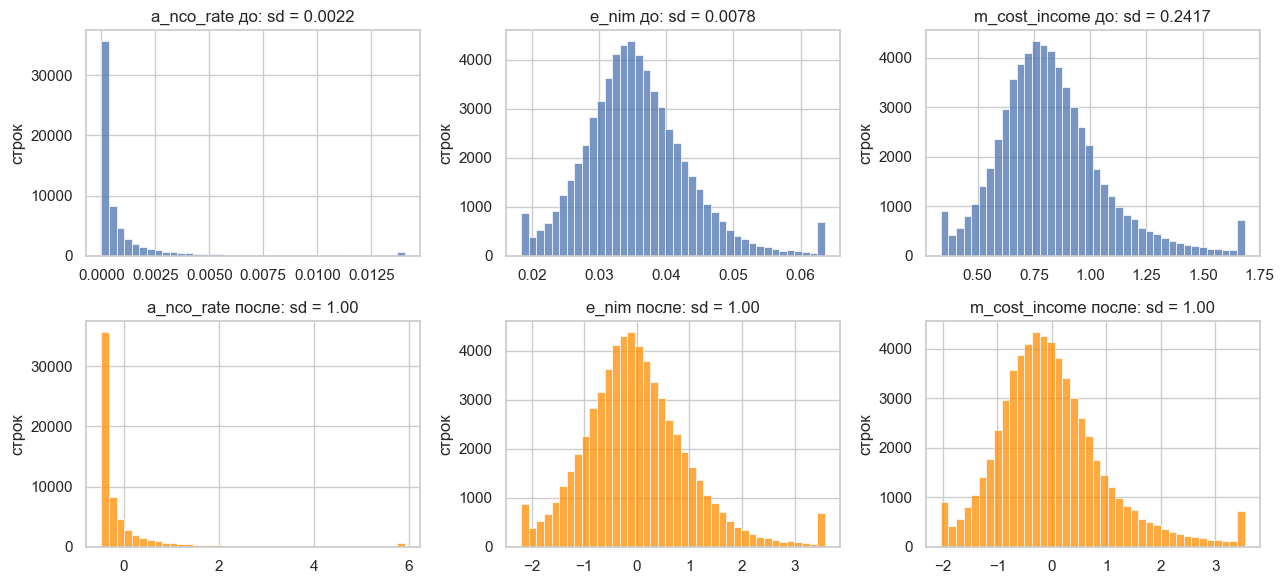

In [45]:
SHOW = ["a_nco_rate", "e_nim", "m_cost_income"]

# Стандартизованный пул: та же таблица, но каждая колонка пересчитана по формуле выше
Z_pool = pd.DataFrame(StandardScaler().fit_transform(X_pool), columns=FEATURES)

fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for k, f in enumerate(SHOW):
    # верхний ряд — как есть
    sns.histplot(X_pool[f], bins=40, ax=axes[0, k])
    axes[0, k].set_title(f"{f} до: sd = {X_pool[f].std():.4f}")
    # нижний ряд — после стандартизации
    sns.histplot(Z_pool[f], bins=40, ax=axes[1, k], color="darkorange")
    axes[1, k].set_title(f"{f} после: sd = {Z_pool[f].std():.2f}")
    axes[0, k].set_xlabel("")
    axes[1, k].set_xlabel("")
    axes[0, k].set_ylabel("строк")
    axes[1, k].set_ylabel("строк")

plt.tight_layout()
plt.show()

Сравните верхнюю и нижнюю гистограмму в каждом столбце: **форма не изменилась ни на бин.** Поменялись только числа на горизонтальной оси. Стандартизация — это сдвиг и растяжение шкалы, как перевод из долей в проценты или из рублей в доллары.

Отсюда частая путаница: **стандартизация не делает распределение нормальным.** Длинный правый хвост у списаний был до и остался после. (Высокие столбики на самых краях — след обрезки хвостов из §8.1: туда собрались все значения за 1-м и 99-м перцентилями.)

Мы вообще не можем делать сами распределения нормальными:(

Теперь — все признаки на одной оси.

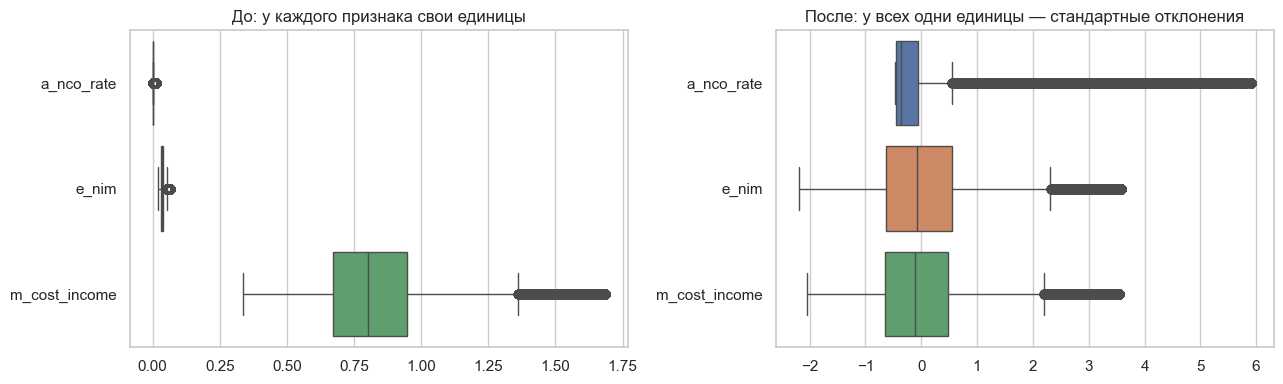

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# boxplot — "ящик с усами": ящик от 25-го до 75-го перцентиля, черта внутри — медиана,
# усы — основной размах значений, точки за усами — отдельные далёкие значения
sns.boxplot(data=X_pool[SHOW], orient="h", ax=axes[0])
axes[0].set_title("До: у каждого признака свои единицы")

sns.boxplot(data=Z_pool[SHOW], orient="h", ax=axes[1])
axes[1].set_title("После: у всех одни единицы — стандартные отклонения")

plt.tight_layout()
plt.show()

Слева списания и маржа сплющены у нуля до неразличимой чёрточки, а cost/income растянут на всю ось: сравнивать их на одной шкале бессмысленно. Справа все три признака живут в одних единицах — «сколько стандартных отклонений от среднего». Ящики с усами маржи и cost/income теперь одного размера, а у списаний видна форма, которую слева было не разглядеть: узкий ящик у нуля и длинный хвост вправо — ровно та гистограмма, что выше.

После стандартизации коэффициент читается как «эффект +1 sd признака» — как во второй лекции, — и штраф одинаков для всех. 

Важная деталь: среднее и sd `StandardScaler` запоминает при `.fit()`. Внутри конвейера и внутри кросс-валидации он учится **только на обучающей части**. Фитимся только на трейне, никогда - на тесте!

## 9. Ridge

### 9.1 Формула

МНК минимизирует RSS. **Ridge** (гребневая регрессия) минимизирует RSS плюс штраф за сумму квадратов коэффициентов:

$$ \sum_{i=1}^{n} \big(y_i - \hat y_i\big)^2 \; + \; \lambda \sum_{j=1}^{p} \beta_j^2 $$

* $\lambda = 0$ — штрафа нет, получаем обычный МНК.
* $\lambda \to \infty$ — штраф так велик, что все коэффициенты стягиваются к нулю, и модель предсказывает просто среднее.
* Свободный член не штрафуется: сдвиг прямой по высоте ничем не опасен.

Между этими крайностями — компромисс. В `sklearn` $\lambda$ называется `alpha`.

### 9.2 Две чаши

Вспомните чашу RSS из §3 второй лекции: RSS как поверхность над плоскостью коэффициентов, дно — оценка МНК. Штраф $\lambda(\beta_1^2 + \beta_2^2)$ — это **вторая чаша**, круглая, с дном в нуле. Ridge ищет дно их **суммы**.

Нарисуем это буквально на двух признаках — близнецах капитала. Возьмём одну из выборок по 300 строк, в которой МНК особенно сильно развёл близнецов в разные стороны (далее мы увидим, что так бывает часто). Из отклика вычтем среднее: тогда свободный член не нужен, у модели ровно два коэффициента, и RSS — поверхность над плоскостью.

In [47]:
from sklearn.linear_model import Ridge

# 300 строк пула; оба близнеца стандартизованы
idx_bowl = X_pool.sample(300, random_state=SEED + 2).index
x_eq = StandardScaler().fit_transform(X_pool.loc[idx_bowl, ["c_equity_assets"]]).ravel()     # .ravel() — в одномерный массив
x_t1 = StandardScaler().fit_transform(X_pool.loc[idx_bowl, ["c_tier1_leverage"]]).ravel()
y_bowl = (y_pool.loc[idx_bowl] - y_pool.loc[idx_bowl].mean()).to_numpy()   # вычли среднее
X_bowl = np.column_stack([x_eq, x_t1])                                      # две колонки рядом

# МНК без свободного члена (fit_intercept=False), коэффициенты в б.п. на +1 sd
b_ols = LinearRegression(fit_intercept=False).fit(X_bowl, y_bowl).coef_ * 10_000
print(f"МНК: капитал / активы {b_ols[0]:+.1f} б.п., tier-1 {b_ols[1]:+.1f} б.п.")

# Сетка коэффициентов в б.п.
B_EQ, B_T1 = np.meshgrid(np.linspace(-45, 35, 80), np.linspace(-25, 80, 80))

LAM = 300                                  # сила штрафа для картинки
rss_bowl = np.zeros(B_EQ.shape)
for i in range(B_EQ.shape[0]):
    for j in range(B_EQ.shape[1]):
        b_eq = B_EQ[i, j] / 10_000         # из б.п. обратно в доли
        b_t1 = B_T1[i, j] / 10_000
        rss_bowl[i, j] = np.sum((y_bowl - b_eq * x_eq - b_t1 * x_t1) ** 2)

penalty_bowl = LAM * ((B_EQ / 10_000) ** 2 + (B_T1 / 10_000) ** 2)
total_bowl = rss_bowl + penalty_bowl

# Точное решение ridge при этом штрафе — для красной точки на третьей чаше
b_ridge = Ridge(alpha=LAM, fit_intercept=False).fit(X_bowl, y_bowl).coef_ * 10_000
print(f"ridge при alpha = {LAM}: капитал / активы {b_ridge[0]:+.1f} б.п., tier-1 {b_ridge[1]:+.1f} б.п.")

МНК: капитал / активы -24.5 б.п., tier-1 +61.2 б.п.
ridge при alpha = 300: капитал / активы +5.2 б.п., tier-1 +18.5 б.п.


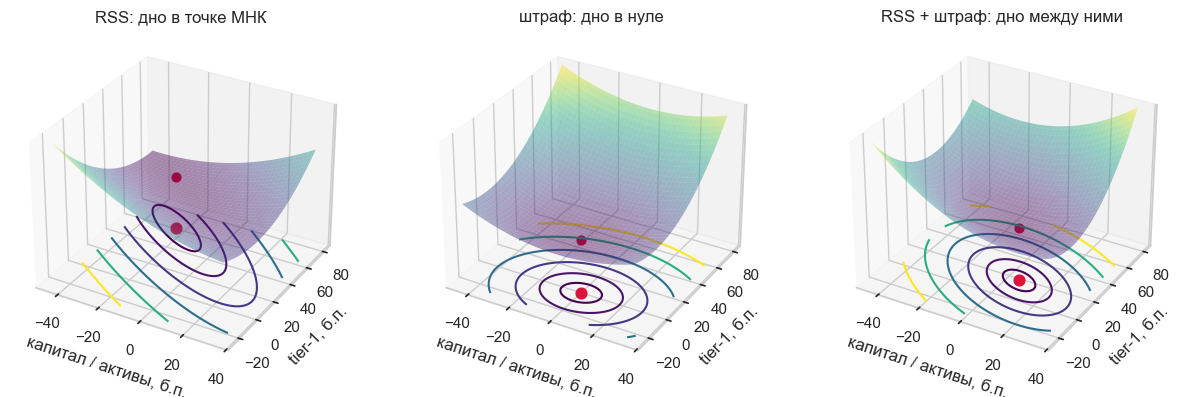

In [48]:
fig = plt.figure(figsize=(15, 5))
panels = [(rss_bowl, b_ols, "RSS: дно в точке МНК"),
          (penalty_bowl, [0, 0], "штраф: дно в нуле"),
          (total_bowl, b_ridge, "RSS + штраф: дно между ними")]

for k, (surface, bottom, title) in enumerate(panels):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    floor = surface.min() - 0.6 * (surface.max() - surface.min())   # высота "пола" под чашей
    ax.plot_surface(B_EQ, B_T1, surface, cmap="viridis", alpha=0.45, edgecolor="none")

    # линии уровня той же поверхности, спроецированные на пол (zdir="z", offset=floor)
    levels = surface.min() + (surface.max() - surface.min()) * np.array([0.01, 0.04, 0.1, 0.2, 0.35, 0.55])
    ax.contour(B_EQ, B_T1, surface, levels=levels, zdir="z", offset=floor, cmap="viridis")

    # дно: на самой чаше и его проекция на пол
    ax.scatter([bottom[0]], [bottom[1]], [surface.min()], color="crimson", s=40, depthshade=False)
    ax.scatter([bottom[0]], [bottom[1]], [floor], color="crimson", s=60, depthshade=False)

    ax.set_zlim(floor, surface.max())
    ax.set_zticks([])                      # абсолютная высота чаш нам не важна
    ax.set_xlabel("капитал / активы, б.п.")
    ax.set_ylabel("tier-1, б.п.")
    ax.set_title(title)
    ax.view_init(elev=30, azim=-60)

plt.show()

Под каждой чашей на «полу» нарисованы её линии уровня — так форму читать проще, чем по самой поверхности.

* **Левая чаша — RSS.** Линии уровня — вытянутые эллипсы: чаша не круглая, а похожа на длинную лощину. Вдоль неё можно увеличивать одного близнеца и уменьшать другого почти без потери RSS. Это та самая лощина коллинеарности, о которой мы говорили во второй лекции.
* **Средняя чаша — штраф.** Линии уровня — круги: чаша одинаково крутая во все стороны, дно в нуле.
* **Правая чаша — сумма.** Эллипсы стали круглее, а дно сдвинулось от МНК к нулю.

Сверху, линиями уровня, видно, куда именно оно сдвигается. Проследим, где оказывается дно суммы при разных $\lambda$.

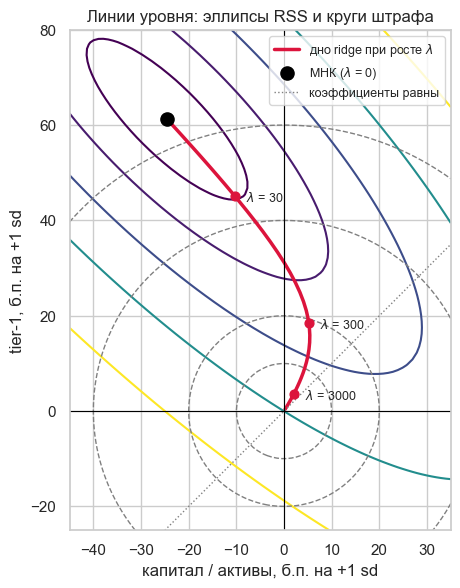

In [49]:
lambdas = np.logspace(0, 4.5, 60)          # от 1 до ~30 000
ridge_path_2d = []
for lam in lambdas:
    ridge_path_2d.append(Ridge(alpha=lam, fit_intercept=False).fit(X_bowl, y_bowl).coef_ * 10_000)
ridge_path_2d = np.array(ridge_path_2d)

fig, ax = plt.subplots(figsize=(7, 6.5))
# эллипсы RSS: линии, где RSS больше минимума на 0.5%, 2%, 5%, 10%, 20%
ax.contour(B_EQ, B_T1, rss_bowl, levels=rss_bowl.min() * np.array([1.005, 1.02, 1.05, 1.1, 1.2]), cmap="viridis")
# круги штрафа: радиусы 10, 20, 40, 60 б.п.
ax.contour(B_EQ, B_T1, penalty_bowl, levels=LAM * (np.array([10, 20, 40, 60]) / 10_000) ** 2,
           colors="grey", linestyles="--", linewidths=1)

ax.plot(ridge_path_2d[:, 0], ridge_path_2d[:, 1], color="crimson", lw=2.5, label="дно ridge при росте $\\lambda$")
ax.scatter([b_ols[0]], [b_ols[1]], s=90, color="black", zorder=5, label="МНК ($\\lambda$ = 0)")
for lam in [30, 300, 3000]:                # подписываем три точки пути
    b = Ridge(alpha=lam, fit_intercept=False).fit(X_bowl, y_bowl).coef_ * 10_000
    ax.scatter([b[0]], [b[1]], s=40, color="crimson", zorder=5)
    ax.annotate(f"$\\lambda$ = {lam}", (b[0], b[1]), textcoords="offset points", xytext=(8, -4), fontsize=9)

ax.plot([-25, 80], [-25, 80], color="grey", lw=1, ls=":", label="коэффициенты равны")
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_aspect("equal")                     # одинаковый масштаб осей, иначе круги станут овалами
ax.set_xlim(-45, 35)
ax.set_ylim(-25, 80)
ax.set_title("Линии уровня: эллипсы RSS и круги штрафа")
ax.set_xlabel("капитал / активы, б.п. на +1 sd")
ax.set_ylabel("tier-1, б.п. на +1 sd")
ax.legend(loc="upper right", fontsize=9)
plt.show()

Читаем путь от чёрной точки к нулю:

* **При слабом штрафе** дно сползает **вдоль лощины RSS**: там сдвиг почти ничего не стоит по RSS, а штраф уменьшается заметно. Разные знаки исчезают — оба коэффициента становятся положительными и сближаются.
* **При сильном штрафе** оба коэффициента вместе стягиваются к нулю.

Это и есть механизм, который мы увидим в далее на ста выборках: ridge не даёт близнецам разбегаться в разные стороны, потому что разбег вдоль лощины МНК «бесплатен» с тз RSS, а для штрафа — дорог.

### 9.3 Путь коэффициентов

Возьмём 300 случайных строк из пула и оценим ridge на одиннадцати исходных признаках при $\lambda$ от 0.01 до 100 000.

In [50]:
# 300 случайных строк пула
idx300 = X_pool.sample(300, random_state=SEED).index
X300 = X_pool.loc[idx300]
y300 = y_pool.loc[idx300]
g300 = pool.loc[idx300, "cert"]            # банки этих строк — для деления по банкам

# Стандартизируем, чтобы коэффициенты были в "б.п. ROA на +1 sd признака"
Z300 = StandardScaler().fit_transform(X300)

# np.logspace(-2, 5, 50) — 50 чисел от 10^-2 до 10^5, равномерно в логарифмах
alphas = np.logspace(-2, 5, 50)

paths = []
for a in alphas:
    ridge = Ridge(alpha=a).fit(Z300, y300)
    paths.append(ridge.coef_ * 10_000)     # коэффициенты в б.п.

ridge_paths = pd.DataFrame(paths, index=alphas, columns=FEATURES)

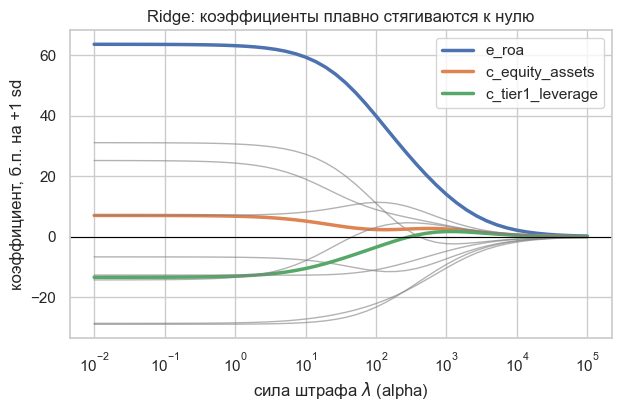

In [51]:
for f in FEATURES:
    if f in ["c_equity_assets", "c_tier1_leverage", "e_roa"]:
        plt.plot(ridge_paths.index, ridge_paths[f], lw=2.5, label=f)   # выделяем три признака
    else:
        plt.plot(ridge_paths.index, ridge_paths[f], lw=1, color="grey", alpha=0.6)

plt.axhline(0, color="black", lw=0.8)
plt.xscale("log")
plt.title("Ridge: коэффициенты плавно стягиваются к нулю")
plt.xlabel("сила штрафа $\\lambda$ (alpha)")
plt.ylabel("коэффициент, б.п. на +1 sd")
plt.legend()
plt.show()

Слева, при слабом штрафе, коэффициенты такие же, как у МНК. Справа все стянуты к нулю.

Посмотрите на двух близнецов капитала. При слабом штрафе у них **разные знаки** и заметная величина: МНК делит между ними общий эффект как придётся (§11.1 второй лекции). По мере роста штрафа они **сходятся** друг к другу и только потом вместе уходят к нулю. Ridge не любит, когда два почти одинаковых признака тянут в разные стороны: дешевле по штрафу поделить эффект поровну.

Сегодняшний ROA держится дольше всех — он самый полезный признак, и штрафу приходится долго его увещевать.

### 9.4 Выбираем $\lambda$ кросс-валидацией

Какой штраф взять? Это такая же ручка гибкости, как степень полинома или $k$, — и выбирается она так же: кросс-валидацией. Теперь на тех же 300 строках возьмём все 77 признаков.

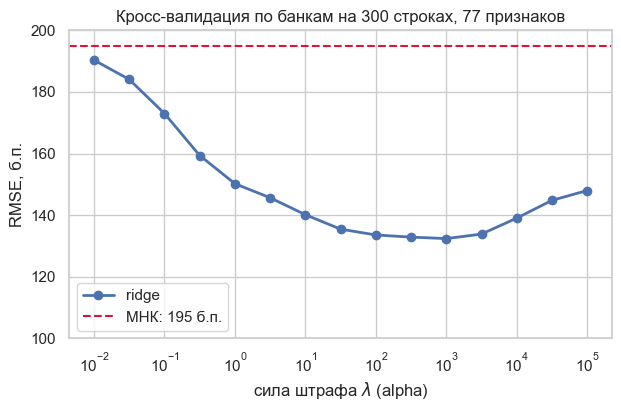

лучшая alpha: 1000.0


In [52]:
alpha_grid = np.logspace(-2, 5, 15)
cv_group10 = GroupKFold(n_splits=10)       # деление по банкам — правило из §5

ridge_curve = []
for a in alpha_grid:
    model = make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(), Ridge(alpha=a))
    ridge_curve.append(cv_rmse(model, X300, y300, cv_group10, groups=g300))

best_alpha = alpha_grid[int(np.argmin(ridge_curve))]
ols_cv = cv_rmse(ols_poly(), X300, y300, cv_group10, groups=g300)

plt.plot(alpha_grid, ridge_curve, "o-", lw=2, label="ridge")
plt.axhline(ols_cv, color="crimson", ls="--", label=f"МНК: {ols_cv:.0f} б.п.")
plt.xscale("log")
plt.ylim(100, 200)
plt.title("Кросс-валидация по банкам на 300 строках, 77 признаков")
plt.xlabel("сила штрафа $\\lambda$ (alpha)")
plt.ylabel("RMSE, б.п.")
plt.legend()
plt.show()

print("лучшая alpha:", round(best_alpha, 1))

Кривая той же формы, что у $k$ в первой лекции: слева слишком гибкая модель (штраф слабый, это почти МНК), справа слишком жёсткая (всё стянуто к среднему), минимум посередине. Красная пунктирная линия — МНК: он хуже ridge при любом штрафе на графике.

Проверим выбранную модель на тестовых банках. Тест мы пока «не открывали» для выбора — используем его только чтобы показать эффект.

In [53]:
ols300 = ols_poly().fit(X300, y300)
ridge300 = make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                         Ridge(alpha=best_alpha)).fit(X300, y300)

print(f"МНК, 77 признаков, 300 строк:   {rmse_bp(y_test, ols300.predict(X_test)):.0f} б.п. на тестовых банках")
print(f"ridge, 77 признаков, 300 строк: {rmse_bp(y_test, ridge300.predict(X_test)):.0f} б.п.")

МНК, 77 признаков, 300 строк:   167 б.п. на тестовых банках
ridge, 77 признаков, 300 строк: 112 б.п.


### 9.5 Ridge против МНК на разном числе строк

Повторим эксперимент §8.2 и добавим ridge. Чтобы не писать цикл по $\lambda$ каждый раз, возьмём `RidgeCV`: он сам перебирает переданные значения штрафа и выбирает лучшее кросс-валидацией (быстрой формулой leave-one-out, её придумали специально для ridge).

In [54]:
from sklearn.linear_model import RidgeCV

ridge_errs = []
for n in SIZES:
    reps = 10 if n < len(pool) else 1
    errs = []
    for r in range(reps):
        idx = X_pool.sample(n, random_state=SEED + r).index     # те же строки, что в §8.2
        model = make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                              RidgeCV(alphas=np.logspace(-2, 5, 30)))
        model.fit(X_pool.loc[idx], y_pool.loc[idx])
        errs.append(rmse_bp(y_test, model.predict(X_test)))
    ridge_errs.append(np.median(errs))

size_table["ridge, 77 признаков"] = ridge_errs
size_table.round(1)

,"МНК, 77 признаков","ridge, 77 признаков"
строк в обучении,,
100,452.4,116.0
300,156.5,109.6
1000,117.0,108.2
3000,107.9,106.9
10000,105.8,105.5
62745,104.8,104.8


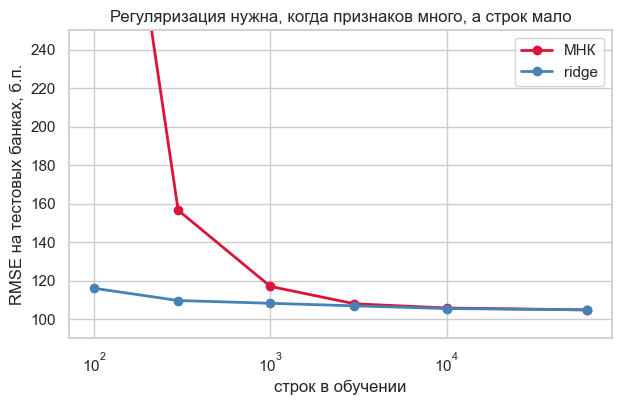

In [55]:
plt.plot(size_table.index, size_table["МНК, 77 признаков"], "o-", lw=2, color="crimson", label="МНК")
plt.plot(size_table.index, size_table["ridge, 77 признаков"], "o-", lw=2, color="steelblue", label="ridge")
plt.xscale("log")
plt.ylim(90, 250)              # точка МНК на 100 строках — выше верхней границы, её значение в таблице
plt.title("Регуляризация нужна, когда признаков много, а строк мало")
plt.xlabel("строк в обучении")
plt.ylabel("RMSE на тестовых банках, б.п.")
plt.legend()
plt.show()

На малых выборках ridge спасает модель: на 100 строках разница многократная. С ростом выборки кривые сходятся, а на полном пуле **совпадают**.

Это честный и важный результат: **на 62 тысячах строк регуляризация ничего не даёт.** Её выигрыш определяется не методом самим по себе, а соотношением числа признаков и числа строк. Если данных много, МНК и так устойчив.

### 9.6 Близнецы капитала

Последнее свойство ridge — то, ради которого его и придумали. Возьмём 100 разных выборок по 300 строк и посмотрим, как ведут себя коэффициенты двух мер капитала у МНК и у ridge.

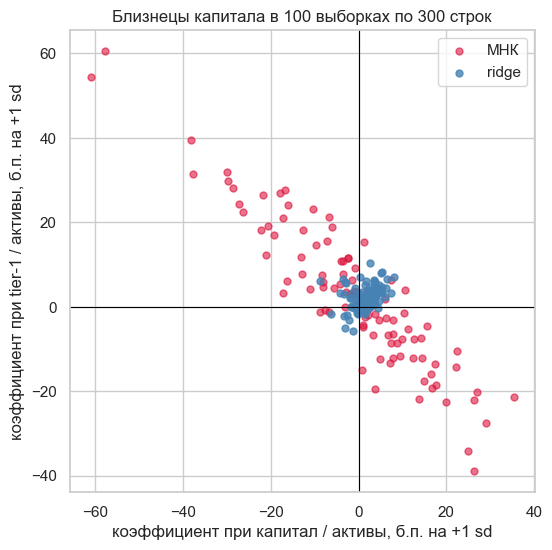

In [56]:
i_eq = FEATURES.index("c_equity_assets")      # .index — позиция элемента в списке
i_t1 = FEATURES.index("c_tier1_leverage")

twins = []
for r in range(100):
    idx = X_pool.sample(300, random_state=SEED + r).index
    Z = StandardScaler().fit_transform(X_pool.loc[idx])
    y_r = y_pool.loc[idx]

    coef_ols = LinearRegression().fit(Z, y_r).coef_ * 10_000
    coef_ridge = Ridge(alpha=300).fit(Z, y_r).coef_ * 10_000    # заметный штраф, чтобы эффект был виден
    twins.append({"МНК: капитал": coef_ols[i_eq], "МНК: tier-1": coef_ols[i_t1],
                  "ridge: капитал": coef_ridge[i_eq], "ridge: tier-1": coef_ridge[i_t1]})

twins = pd.DataFrame(twins)

plt.figure(figsize=(6, 6))
plt.scatter(twins["МНК: капитал"], twins["МНК: tier-1"], s=25, color="crimson", alpha=0.6, label="МНК")
plt.scatter(twins["ridge: капитал"], twins["ridge: tier-1"], s=25, color="steelblue", alpha=0.8, label="ridge")
plt.axhline(0, color="black", lw=0.8)
plt.axvline(0, color="black", lw=0.8)
plt.title("Близнецы капитала в 100 выборках по 300 строк")
plt.xlabel("коэффициент при капитал / активы, б.п. на +1 sd")
plt.ylabel("коэффициент при tier-1 / активы, б.п. на +1 sd")
plt.legend()
plt.show()

In [57]:
opposite_ols = (twins["МНК: капитал"] * twins["МНК: tier-1"] < 0).mean()
opposite_ridge = (twins["ridge: капитал"] * twins["ridge: tier-1"] < 0).mean()

print(f"разные знаки у близнецов: МНК — {opposite_ols:.0%} выборок, ridge — {opposite_ridge:.0%}")
print(f"разброс коэффициента при капитале: МНК — {twins['МНК: капитал'].std():.1f} б.п., "
      f"ridge — {twins['ridge: капитал'].std():.1f} б.п.")

разные знаки у близнецов: МНК — 91% выборок, ridge — 23%
разброс коэффициента при капитале: МНК — 17.1 б.п., ridge — 2.9 б.п.


Красные точки МНК вытянуты вдоль убывающей диагонали: если один близнец получил +30, второй получит около −30. Сумма их эффектов определена неплохо, а **их сплит случаен**, и знаки чаще всего разные. Ровно это мы видели во второй лекции на одной выборке — здесь видно, что так происходит почти всегда.

Синие точки ridge собраны у центра: штраф не даёт близнецам разбегаться в разные стороны, разброс коэффициента в несколько раз меньше, и разные знаки стали редкостью. Цена — сжатие: штраф здесь выбран заметный, и остальные коэффициенты модели он тоже уменьшил (вспомните путь в §9.3). Интерпретировать каждого близнеца по отдельности всё равно не стоит, но модель перестала «шататься» от выборки к выборке.

## 10. Lasso и elastic net

### 10.1 Формула

**Lasso** отличается от ridge одной деталью — штрафует не квадраты коэффициентов, а их модули:

$$ \sum_{i=1}^{n} \big(y_i - \hat y_i\big)^2 \; + \; \lambda \sum_{j=1}^{p} |\beta_j| $$

Следствие этой детали: lasso не просто стягивает коэффициенты к нулю, а **ставит часть из них ровно в ноль**. То есть он заодно **отбирает признаки** (feature selection). Ridge же оставляет в модели все признаки, просто маленькими.

Почему так, видно на тех же близнецах из §9.2. Линии уровня штрафа $|\beta_1| + |\beta_2|$ — не круги, а **ромбы** с углами на осях. Нарисуем рядом путь ridge и путь lasso.

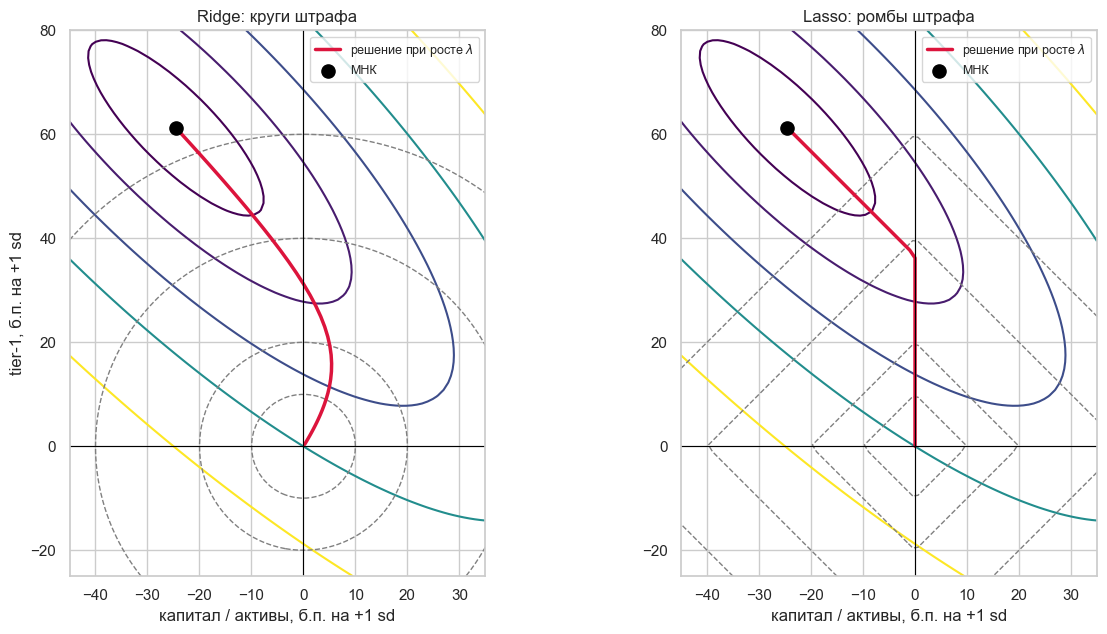

lasso: капитал / активы = 0 начиная с alpha ≈ 0.00050, дальше уменьшается только tier-1


In [58]:
from sklearn.linear_model import Lasso

# Lasso подбирает коэффициенты пошагово. При самых слабых штрафах он не успевает
# сойтись и печатает предупреждение ConvergenceWarning. Такие штрафы кросс-валидация
# всё равно не выбирает, поэтому предупреждения выключаем, чтобы не засоряли экран.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Путь lasso на тех же двух близнецах, что в §9.2
lasso_grid = np.logspace(-6, np.log10(0.005), 60)
lasso_path_2d = []
for a in lasso_grid:
    lasso_path_2d.append(Lasso(alpha=a, fit_intercept=False).fit(X_bowl, y_bowl).coef_ * 10_000)
lasso_path_2d = np.array(lasso_path_2d)

diamond = np.abs(B_EQ) + np.abs(B_T1)      # штраф lasso на той же сетке

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
panels = [(axes[0], ridge_path_2d, penalty_bowl, LAM * (np.array([10, 20, 40, 60]) / 10_000) ** 2,
           "Ridge: круги штрафа"),
          (axes[1], lasso_path_2d, diamond, [10, 20, 40, 60],
           "Lasso: ромбы штрафа")]

for ax, path, pen, pen_levels, title in panels:
    ax.contour(B_EQ, B_T1, rss_bowl, levels=rss_bowl.min() * np.array([1.005, 1.02, 1.05, 1.1, 1.2]), cmap="viridis")
    ax.contour(B_EQ, B_T1, pen, levels=pen_levels, colors="grey", linestyles="--", linewidths=1)
    ax.plot(path[:, 0], path[:, 1], color="crimson", lw=2.5, label="решение при росте $\\lambda$")
    ax.scatter([b_ols[0]], [b_ols[1]], s=90, color="black", zorder=5, label="МНК")
    ax.axhline(0, color="black", lw=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_aspect("equal")
    ax.set_xlim(-45, 35)
    ax.set_ylim(-25, 80)
    ax.set_title(title)
    ax.set_xlabel("капитал / активы, б.п. на +1 sd")
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("tier-1, б.п. на +1 sd")
plt.tight_layout()
plt.show()

# Первый штраф, при котором коэффициент при капитале стал ровно нулём
first_zero = lasso_grid[np.argmax(lasso_path_2d[:, 0] == 0)]
print(f"lasso: капитал / активы = 0 начиная с alpha ≈ {first_zero:.5f}, дальше уменьшается только tier-1")

Слева путь ridge плавно заворачивает к нулю. Ось он пересекает, но не останавливается на ней: оба коэффициента остаются ненулевыми почти при любом $\lambda$.

Справа путь lasso идёт к оси и **упирается** в неё. Коэффициент при капитале становится ровно нулём и больше из нуля не выходит; дальше к нулю ползёт только tier-1 — вдоль оси.

Геометрия простая: эллипсу RSS выгоднее всего коснуться ромба **в углу**, а в углу один из коэффициентов равен нулю. У круга углов нет (кроме квадратуры, разумеется). То же самое алгебраически: у квадрата штраф возле нуля почти исчезает ($0.01^2 = 0.0001$), и доводить коэффициент до точного нуля ridge незачем; у модуля штраф возле нуля такой же крутой, как вдали, и маленький коэффициент выгоднее обнулить совсем.

### 10.2 Путь коэффициентов

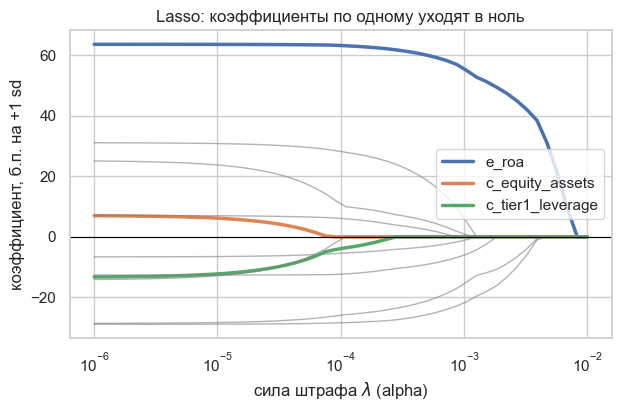

признаков в модели при alpha = 1e-5, 1e-4, 1e-3: [11, 9, 7]


In [59]:
# Теперь все 11 признаков. У lasso шкала штрафа другая, поэтому и сетка другая
lasso_alphas = np.logspace(-6, -2, 50)

paths = []
for a in lasso_alphas:
    lasso = Lasso(alpha=a, max_iter=10_000).fit(Z300, y300)   # max_iter — сколько шагов разрешено на подбор
    paths.append(lasso.coef_ * 10_000)

lasso_paths = pd.DataFrame(paths, index=lasso_alphas, columns=FEATURES)

for f in FEATURES:
    if f in ["c_equity_assets", "c_tier1_leverage", "e_roa"]:
        plt.plot(lasso_paths.index, lasso_paths[f], lw=2.5, label=f)
    else:
        plt.plot(lasso_paths.index, lasso_paths[f], lw=1, color="grey", alpha=0.6)

plt.axhline(0, color="black", lw=0.8)
plt.xscale("log")
plt.title("Lasso: коэффициенты по одному уходят в ноль")
plt.xlabel("сила штрафа $\\lambda$ (alpha)")
plt.ylabel("коэффициент, б.п. на +1 sd")
plt.legend()
plt.show()

# (коэффициент != 0).sum(axis=1) — сколько признаков осталось при каждом штрафе
nonzero = (lasso_paths != 0).sum(axis=1)
print("признаков в модели при alpha = 1e-5, 1e-4, 1e-3:",
      nonzero.iloc[[12, 25, 37]].tolist())

В отличие от ridge, линии не подползают к нулю плавно, а **упираются** в него и остаются там. С ростом штрафа признаки выходят из модели по одному; последним держится сегодняшний ROA.

### 10.3 Lasso на 77 признаках

`LassoCV` выбирает штраф кросс-валидацией, как `RidgeCV`. Посмотрим, сколько из 77 признаков он оставит на тех же 300 строках — и каких.

In [60]:
from sklearn.linear_model import LassoCV

# cv=10 — 10 блоков; среди 300 случайных строк пула почти все из разных банков
lasso300 = make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                         LassoCV(alphas=np.logspace(-6, -2, 30), cv=10, max_iter=10_000))
lasso300.fit(X300, y300)

coefs = lasso300[-1].coef_                              # [-1] — последний шаг конвейера, сам lasso
names = lasso300[0].get_feature_names_out()             # [0] — первый шаг: имена 77 колонок
kept = pd.Series(coefs * 10_000, index=names)
kept = kept[kept != 0].sort_values()

print("признаков оставлено:", len(kept), "из", len(names))
print(f"ошибка на тестовых банках: МНК {rmse_bp(y_test, ols300.predict(X_test)):.0f}, "
      f"ridge {rmse_bp(y_test, ridge300.predict(X_test)):.0f}, "
      f"lasso {rmse_bp(y_test, lasso300.predict(X_test)):.0f} б.п.")
kept.round(1).to_frame("коэффициент, б.п. на +1 sd")

признаков оставлено: 6 из 77
ошибка на тестовых банках: МНК 167, ridge 112, lasso 116 б.п.


,"коэффициент, б.п. на +1 sd"
a_cre_concentration l_brokered_share,-38.1
a_npl_gross_loans a_cre_concentration,-5.2
e_roa l_brokered_share,1.1
e_roa e_nim,1.4
e_roa a_cre_concentration,13.6
e_roa,30.5


Lasso оставил несколько признаков из 77, и по ошибке на новых банках он в одной лиге с ridge. Имена в таблице читаются так: `e_roa e_nim` — произведение двух признаков; квадрат выглядел бы как `e_roa^2`.

Модель, в которой несколько слагаемых вместо 77, гораздо легче показать рисковику или боссу. Это главная практическая причина любить lasso!

### 10.4 Но отбор нестабилен

Соблазнительно прочитать результат lasso как «вот важные признаки, остальные не нужны». Проверим на близнецах капитала: в тех же 100 выборках по 300 строк посмотрим, кого из них lasso оставляет.

In [61]:
choice = []
for r in range(100):
    idx = X_pool.sample(300, random_state=SEED + r).index
    Z = StandardScaler().fit_transform(X_pool.loc[idx])
    lasso = LassoCV(alphas=np.logspace(-6, -2, 30), cv=10, max_iter=10_000).fit(Z, y_pool.loc[idx])

    eq_in = lasso.coef_[i_eq] != 0          # остался ли капитал / активы
    t1_in = lasso.coef_[i_t1] != 0          # остался ли tier-1
    if eq_in and t1_in:
        choice.append("оба")
    elif eq_in:
        choice.append("только капитал / активы")
    elif t1_in:
        choice.append("только tier-1")
    else:
        choice.append("ни одного")

pd.Series(choice).value_counts().to_frame("выборок из 100")

,выборок из 100
ни одного,45
только tier-1,22
только капитал / активы,21
оба,12


От выборки к выборке lasso оставляет то одного близнеца, то другого, то обоих, а часто и ни одного — их общую работу забирают другие признаки. Какой из двух коррелированных признаков «выжил» — во многом дело случая.

> **Правило.** Нулевой коэффициент lasso не значит «признак не важен». Он значит «в этой выборке без него можно было обойтись, потому что его работу сделал кто-то другой».

### 10.5 Elastic net

**Elastic net** смешивает оба штрафа:

$$ \text{RSS} \; + \; \lambda \Big( \rho \sum_j |\beta_j| \; + \; (1 - \rho) \sum_j \beta_j^2 \Big) $$

При $\rho = 1$ это lasso, при $\rho = 0$ — ridge. Посередине модель умеет и обнулять признаки, как lasso, и держать коррелированные признаки вместе, как ridge. В `sklearn` $\rho$ называется `l1_ratio`, и его тоже можно выбрать кросс-валидацией.

In [62]:
from sklearn.linear_model import ElasticNetCV

enet300 = make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                        ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-6, -2, 30),
                                     cv=10, max_iter=10_000))
enet300.fit(X300, y300)

print("выбранная доля lasso (l1_ratio):", enet300[-1].l1_ratio_)
print("признаков оставлено:", (enet300[-1].coef_ != 0).sum(), "из 77")
print(f"ошибка на тестовых банках: {rmse_bp(y_test, enet300.predict(X_test)):.0f} б.п.")

выбранная доля lasso (l1_ratio): 0.5
признаков оставлено: 6 из 77
ошибка на тестовых банках: 116 б.п.


Шпаргалка:

| Метод | Что делает с коэффициентами | Когда брать |
|---|---|---|
| МНК | ничего | строк намного больше, чем признаков |
| ridge | стягивает все, никого не обнуляет | много коррелированных признаков, нужен устойчивый прогноз |
| lasso | часть обнуляет | нужна короткая модель, которую можно показать людям |
| elastic net | и то и другое | много признаков, и они группами коррелированы |

Во всех трёх случаях сила штрафа — ручка гибкости, и выбирается она кросс-валидацией **с тем же делением, что и всё остальное**: по банкам, по времени.

## 11. Итоговый протокол

Соберём всё в одну честную оценку. Модель будут применять **к новым банкам** и **в будущем**, значит, тест должен быть и тем и другим:

* **обучение:** банки из пула, строки до 2015 года включительно;
* **зазор:** 2016 год — горизонт прогноза;
* **тест:** банки из отложенных 30 %, строки с 2017 года.

Все решения — границы клипов и фильтрация, стандартизация, сила штрафа — принимаются только по обучающей части, кросс-валидацией по банкам. Тест прогоняем **один раз**, в самом конце.

И обязательно сравниваем с **наивными прогнозами**: без них непонятно, много ли умеет модель.

In [63]:
train = fc[~fc["cert"].isin(test_certs) & (year <= 2015)]
final_test = fc[fc["cert"].isin(test_certs) & (year >= 2017)]
print("обучение:", len(train), "строк | тест:", len(final_test), "строк")

# Границы обрезки — только по обучению
lo_tr = train[FEATURES].quantile(0.01)
hi_tr = train[FEATURES].quantile(0.99)
X_tr = train[FEATURES].clip(lo_tr, hi_tr, axis=1)
X_te = final_test[FEATURES].clip(lo_tr, hi_tr, axis=1)
y_tr = train["roa_next"]
y_te = final_test["roa_next"]

# Заранее нарезанные блоки по банкам — их поймут RidgeCV и LassoCV
folds = list(GroupKFold(n_splits=5).split(X_tr, y_tr, groups=train["cert"]))

обучение: 46547 строк | тест: 5958 строк


In [ ]:
models = {
    "МНК, 11 признаков": make_pipeline(StandardScaler(), LinearRegression()),
    "МНК, 77 признаков": ols_poly(),
    "ridge, 77 признаков": make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                                         RidgeCV(alphas=np.logspace(-2, 5, 30), cv=folds)),
    "lasso, 77 признаков": make_pipeline(PolynomialFeatures(2, include_bias=False), StandardScaler(),
                                         LassoCV(alphas=np.logspace(-6, -2, 30), cv=folds, max_iter=10_000)),
}

results = {
    # наивный прогноз 1: всем банкам — средний ROA через год по обучению
    "наивный: среднее по обучению": rmse_bp(y_te, np.full(len(y_te), y_tr.mean())),
    # наивный прогноз 2: ROA через год равен сегодняшнему
    "наивный: ROA через год = ROA сегодня": rmse_bp(y_te, final_test["e_roa"]),
}
for name, model in models.items():            # .items() — пары (имя, модель)
    model.fit(X_tr, y_tr)
    results[name] = rmse_bp(y_te, model.predict(X_te))

pd.Series(results).round(1).to_frame("RMSE на тесте, б.п.")

,"RMSE на тесте, б.п."
наивный: среднее по обучению,102.8
наивный: ROA через год = ROA сегодня,96.3
"МНК, 11 признаков",86.8
"МНК, 77 признаков",85.4
"ridge, 77 признаков",84.9
"lasso, 77 признаков",84.6


Читаем таблицу:

* **Наивные прогнозы** задают планку. «Завтра будет как сегодня» уже заметно лучше среднего — прибыльность устойчива.
* **Модели обыгрывают «как сегодня»** ещё примерно на 10 б.п. Это и есть то, что добавляют показатели CAMELS к сегодняшнему ROA.
* **Регуляризация и 77 признаков** добавляют к простому МНК один-два базисных пункта. На 46 тысячах строк это ожидаемо. Честный вывод — квадраты и произведения здесь почти не помогают, и при прочих равных стоит выбрать простую модель (парсимониальность).

И последняя проверка — сравним с тем, что пообещала бы кросс-валидация на обучении.

In [65]:
cv_train = cv_rmse(make_pipeline(StandardScaler(), LinearRegression()), X_tr, y_tr,
                   GroupKFold(n_splits=5), groups=train["cert"])
print(f"МНК, 11 признаков: кросс-валидация на обучении {cv_train:.0f} б.п., тест {results['МНК, 11 признаков']:.0f} б.п.")

МНК, 11 признаков: кросс-валидация на обучении 116 б.п., тест 87 б.п.


Тест оказался **лучше** оценки на обучении. Это не ошибка и не повод радоваться: обучение включает кризис 2008–2010, а тест — спокойные годы после 2017-го. Ошибка прогноза зависит от периода, и число «на тесте» честно только **для этого периода**. В следующий кризис оно будет другим (только если кризис точь-в-точь не повторится).

### Протокол валидации: самое важное

1. **Что прогнозируем и на какой горизонт.** ROA через 4 квартала.
2. **К кому модель применяют.** К новым банкам и в будущем → деление по банкам и по времени, зазор в один год.
3. **Где принимаются решения.** Фильтры, границы, стандартизация, $\lambda$, $k$ — только на обучении, кросс-валидацией по банкам.
4. **Проверка признаков на утечку.** Про каждый: известен ли он в момент прогноза.
5. **С чем сравниваем.** Наивные прогнозы; тест открывается один раз.
6. **Что осталось за кадром.** Фильтр по будущему ROA убрал дефолты; тестовый период спокойный.

## Итого

1. **Ошибка на обучающей выборке** всегда падает с ростом гибкости модели, поэтому выбирать модель по ней нельзя.
2. **Отложенная выборка** честная, но её оценка сильно зависит от деления и завышена: модель обучалась на части данных.
3. **k-fold кросс-валидация** усредняет $k$ делений и даёт устойчивую оценку. На практике $k = 5$ или $10$; leave-one-out почти то же, но в разы дольше. Модели кросс-валидации временные: она выбирает настройку, а финальную модель обучают заново на всех данных.
4. **Бутстрап** оценивает разброс любой статистики по одной выборке — выборками с возвращением из неё самой.
5. **В панели независимая единица — банк.** Бутстрап надо делать по банкам, кросс-валидацию — делить по банкам. Иначе разброс занижен, а модель выбрана неправильно (**сущностная утечка**).
6. **Прогноз проверяют на будущем**, с зазором в горизонт прогноза. Случайное деление строк прячет кризисы (**временная утечка**).
7. **Признак, который знает ответ**, даёт блестящие и бесполезные результаты. Про каждый признак спрашиваем: знал бы я его в момент прогноза? Всё, что считается по многим строкам, считаем только по прошлому (**целевая утечка**).
8. **Ridge** стягивает коэффициенты к нулю и стабилизирует коррелированные признаки. **Lasso** ещё и обнуляет часть коэффициентов, но его отбор нестабилен. **Elastic net** — смесь.
9. **Регуляризация нужна, когда признаков много относительно строк.** На большой выборке она почти ничего не даёт — и это нормальный результат.
10. **Протокол валидации** — не формальность: каждое его решение меняет число, которое вы понесёте заказчику.

И сквозная мысль лекции: **качество модели — это не свойство модели, а ответ на вопрос «на каких данных и в каких условиях»**.

---

# Домашнее задание

Пройти те же шаги с **другим откликом**: **процентная маржа через год** вместо ROA через год. Маржа — та же переменная `e_nim`, что была откликом в домашних заданиях первых двух лекций.

Копировать код из лекции можно и нужно — менять придётся немного! Смысл задания не в том, чтобы написать новый код, а в том, чтобы **выбрать** схему проверки — и уметь объяснить каждый выбор.

### 1. Таблица для прогноза

`TODO(hw3-a)`. Постройте колонку `nim_next` — процентная маржа того же банка через 4 квартала — **до фильтра**, с проверкой, что между датами ровно год. Примените свой фильтр (можно взять из прошлых домашек) и сохраните таблицу в `hw`. Напечатайте число строк, число банков и корреляцию маржи сегодня и через год.

Ниже словами: какие строки выпали из таблицы и о какой совокупности банков теперь ваши выводы.

In [66]:
# TODO(hw3-a): nim_next через shift(-4) до фильтра, проверка дат, фильтр -> hw,
# число строк и банков, корреляция e_nim и nim_next.

> _Ваш ответ (2–3 предложения):_

### 2. Степень полинома

`TODO(hw3-b)`. Возьмите 500 случайных строк из `hw` и один признак. Для степеней от 1 до 8 посчитайте ошибку прогноза `nim_next`: на обучающей выборке, на десяти делениях пополам и 10-fold кросс-валидацией. Постройте картинку, как в §3.4 (слева скорее всего есть оглавление).

Ниже словами: какую степень вы выбираете и почему не ту, что лучшая на обучающей выборке.

In [67]:
# TODO(hw3-b): 500 строк, степени 1..8, ошибка на обучении,
# 10 делений пополам, 10-fold, картинка.

> _Ваш ответ (2–3 предложения):_

### 3. Бутстрап

`TODO(hw3-c)`. Возьмите 100 случайных банков со всей историей и оцените `e_nim ~ X` с одним признаком на ваш выбор. Сравните в одной таблице стандартную ошибку наклона: обычную, HC1, кластерную по банкам, бутстрап по строкам и бутстрап по банкам (по 300 повторов).

Ниже словами: какие числа совпали между собой и почему.

In [68]:
# TODO(hw3-c): 100 банков, пять стандартных ошибок одного наклона в одной таблице.

> _Ваш ответ (2–3 предложения):_

### 4. Утечки

`TODO(hw3-d)`. Прогноз `nim_next` по своим признакам:

1. возьмите 400 случайных банков и сравните случайную кросс-валидацию и кросс-валидацию по банкам для KNN при разных $k$ (таблица и картинка, как в §5.3);
2. на всей таблице `hw` постройте прогноз шаг за шагом по годам для линейной регрессии (таблица и столбиковая диаграмма, как в §6.2).

Ниже ~100 слов: какое $k$ выбирает каждая схема, в какие годы прогноз маржи хуже всего и совпадает ли это с кризисом.

In [69]:
# TODO(hw3-d): KNN со случайным и групповым делением; прогноз шаг за шагом по годам.

> _Ваш ответ (~100 слов):_

### 5. Регуляризация

`TODO(hw3-e)`. Отложите 30 % банков в тест. Обрежьте (заклипайте) хвосты признаков по обучающему пулу, сделайте квадраты и произведения. На 300 случайных строках пула обучите МНК, ridge и lasso (штраф — кросс-валидацией) и сравните ошибку на тестовых банках. Напечатайте признаки, которые оставил lasso.

Ниже ~100 слов: помогла ли регуляризация и можно ли по списку lasso судить, какие признаки важны для маржи.

In [70]:
# TODO(hw3-e): тест по банкам, обрезка, 77 признаков, МНК / ridge / lasso на 300 строках,
# ошибка на тесте, список признаков lasso.

> _Ваш ответ (~100 слов):_

### 6. Протокол валидации

`TODO(hw3-f)`. Соберите итоговую оценку, как в §11: обучение — банки пула до 2015 года, тест — отложенные банки с 2017 года. Сравните две модели на ваш выбор с двумя наивными прогнозами.

Ниже ~150 слов: **ваш протокол валидации** по шести пунктам из §11. Этот текст — черновик раздела вашего итогового отчёта, он еще очень пригодится!

In [71]:
# TODO(hw3-f): обучение до 2015 года на банках пула, тест с 2017 года на отложенных банках,
# две модели и два наивных прогноза в одной таблице.

> _Ваш протокол (~150 слов):_